# Motor de Stress Testing en Python
## Escenarios de Estres y Cambios de Regimen de Mercado

**Practica B2-2 - Modulo de Gestion de Riesgos**

| | |
|---|---|
| **Autor** |  Albert y Raul |
| **Fecha** | Febrero 2026 |
| **Periodo de datos** | 01-01-2006 a la fecha |


In [1]:
# Descomentar en Google Colab:
!pip install hmmlearn yfinance -q



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ALBER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


---
## Fase 0.1: Configuracion y librerias

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from datetime import datetime
import yfinance as yf
from scipy import stats
from scipy.stats import skew, kurtosis, kendalltau, t as t_dist
from scipy.special import gammaln
from scipy.optimize import minimize_scalar
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

# Colores segun enunciado: Blanco=Calma, Azul=Crisis
COLOR_CALMA = "#FFFFFF"
COLOR_CRISIS = "#1A5276"
COLOR_CALMA_FILL = "#E8F8F5"  # verde suave para fondo calma

SEED = 42
np.random.seed(SEED)

START_DATE = "2006-01-01"
END_DATE = datetime.now().strftime("%Y-%m-%d")
N_SIMULATIONS = 10_000
HORIZON_DAYS = 126  # 6 meses habiles

# Flag de metodo de simulacion
USE_COPULAS = True  # True=t-copula (lento), False=bootstrap (rapido)

# Trazabilidad de fuentes por bloque de datos
DATA_SOURCES = {
    "Acciones/ETFs": "Yahoo Finance (yfinance, precios ajustados)",
    "S&P 500": "Yahoo Finance (^GSPC)",
    "Tipos 10Y/5Y": "Yahoo Finance (^TNX/^FVX; fallback mediante ETFs IEF/SHY)",
    "Credito y liquidez": "Proxies de mercado via ETFs (HYG, LQD, IEF, SHY)",
}

print(f"Periodo: {START_DATE} a {END_DATE}")
print(f"Simulaciones: {N_SIMULATIONS:,} | Horizonte: {HORIZON_DAYS} dias")
print(f"Metodo de simulacion: {'t-Copula' if USE_COPULAS else 'Bootstrap historico'}")


Periodo: 2006-01-01 a 2026-02-15
Simulaciones: 10,000 | Horizonte: 126 dias
Metodo de simulacion: t-Copula


In [3]:
# Universo de activos segun enunciado (18 activos + mercado)
# Nota: para bonos soberanos se usan ETFs liquidos (IEF~10Y, SHY~2Y) como aproximacion operativa.
PORTFOLIO_TICKERS = {
    "AAPL": "Apple", "AMZN": "Amazon", "BAC": "Bank of America",
    "BRK-B": "Berkshire", "CVX": "Chevron", "ENPH": "Enphase",
    "GLD": "Gold ETF", "GME": "GameStop", "GOOGL": "Alphabet",
    "JNJ": "J&J", "JPM": "JPMorgan", "MSFT": "Microsoft",
    "NVDA": "NVIDIA", "PG": "P&G", "XOM": "ExxonMobil",
    "IEF": "Treasury 10Y ETF", "SHY": "Treasury 2Y ETF", "HYG": "High Yield ETF",
}
MARKET_TICKER = "^GSPC"  # S&P 500 como proxy de mercado
YIELD_TICKERS = {"^TNX": "Yield 10Y", "^FVX": "Yield 5Y"}  # yields via Yahoo
TICKERS = list(PORTFOLIO_TICKERS.keys())

print(f"Universo de cartera: {len(TICKERS)} activos + S&P 500")


Universo de cartera: 18 activos + S&P 500


---
## Fase 0.2: Obtencion y preparacion de datos

In [4]:
# Descargar precios de activos de cartera + mercado
all_tickers = TICKERS + [MARKET_TICKER] + list(YIELD_TICKERS.keys())
print(f"Descargando {len(all_tickers)} series...")
raw = yf.download(all_tickers, start=START_DATE, end=END_DATE, progress=True, auto_adjust=True)
prices = raw['Close'].copy()
if isinstance(prices.columns, pd.MultiIndex):
    prices.columns = prices.columns.droplevel(0)

# Separar yields (vienen en nivel, no en precio) hay que separarla de los precios
yield_cols = [c for c in YIELD_TICKERS.keys() if c in prices.columns]
yields_df = prices[yield_cols].copy() if yield_cols else pd.DataFrame(index=prices.index)
prices = prices.drop(columns=yield_cols, errors='ignore')

print(f"Precios: {prices.shape[0]} dias x {prices.shape[1]} activos")
print(f"Yields disponibles: {list(yields_df.columns)}")


Descargando 21 series...


[*********************100%***********************]  21 of 21 completed


Precios: 5061 dias x 19 activos
Yields disponibles: ['^TNX', '^FVX']


### Verificacion de calidad de datos (Sanity Check)

In [5]:
# Comprobar integridad de los datos
na_pct = (prices.isna().sum() / len(prices) * 100).round(2)
duplicates = prices.index.duplicated().sum()

def first_valid_idx(s):
    return s.dropna().index.min() if s.notna().any() else pd.NaT

def last_valid_idx(s):
    return s.dropna().index.max() if s.notna().any() else pd.NaT

coverage = pd.DataFrame({
    "Primer dato": prices.apply(first_valid_idx),
    "Ultimo dato": prices.apply(last_valid_idx),
    "% NA": na_pct,
})

print("DIAGNOSTICO DE DATOS")
print("=" * 60)
print(f"Periodo bruto: {prices.index[0].strftime('%Y-%m-%d')} a {prices.index[-1].strftime('%Y-%m-%d')}")
print(f"Dias totales: {len(prices):,}")
print(f"Indices duplicados: {duplicates}")

na_nonzero = na_pct[na_pct > 0].sort_values(ascending=False)
print("\nNAs por activo (>0%):")
if len(na_nonzero) > 0:
    for ticker, pct in na_nonzero.items():
        print(f"  {ticker}: {pct:.2f}%")
else:
    print("  Ningun activo con NAs")

print("\nCobertura temporal por activo (previa a backfill):")
display(coverage.sort_values("% NA", ascending=False))

print("\nFUENTES DE DATOS")
print("=" * 60)
for bloque, fuente in DATA_SOURCES.items():
    print(f"- {bloque}: {fuente}")


DIAGNOSTICO DE DATOS
Periodo bruto: 2006-01-03 a 2026-02-13
Dias totales: 5,061
Indices duplicados: 0

NAs por activo (>0%):
  ENPH: 31.06%
  HYG: 6.28%

Cobertura temporal por activo (previa a backfill):


,Primer dato,Ultimo dato,% NA
Ticker,,,
ENPH,2012-03-30,2026-02-13,31.06
HYG,2007-04-11,2026-02-13,6.28
AAPL,2006-01-03,2026-02-13,0.00
BAC,2006-01-03,2026-02-13,0.00
AMZN,2006-01-03,2026-02-13,0.00
CVX,2006-01-03,2026-02-13,0.00
BRK-B,2006-01-03,2026-02-13,0.00
GLD,2006-01-03,2026-02-13,0.00
GME,2006-01-03,2026-02-13,0.00



FUENTES DE DATOS
- Acciones/ETFs: Yahoo Finance (yfinance, precios ajustados)
- S&P 500: Yahoo Finance (^GSPC)
- Tipos 10Y/5Y: Yahoo Finance (^TNX/^FVX; fallback mediante ETFs IEF/SHY)
- Credito y liquidez: Proxies de mercado via ETFs (HYG, LQD, IEF, SHY)


### Backfilling con Proxies (Datos Sinteticos)

Algunos activos (`ENPH`, `HYG`) no disponen de datos desde el inicio del periodo de estudio (2006). En lugar de descartar los primeros aÃƒÂ±os (perdiendo eventos cruciales como la Crisis Financiera de 2008), se generÃƒÂ¡ un **backfill sintÃƒÂ©tico** basado en activos proxy:

| Activo | Proxy | JustificaciÃƒÂ³n |
| :--- | :--- | :--- |
| **ENPH** (Enphase Energy) | `XLK` (Technology Select Sector ETF) | ENPH es una small-cap tecnologica del sector solar; XLK captura el factor tecnologico comun |
| **HYG** (High Yield Bond ETF) | `LQD` (Investment Grade Bond ETF) | Ambos son ETFs de renta fija corporativa; LQD cotiza desde 2002 y captura el ciclo de credito |

**Metodologia:** Se ajusta una regresiÃƒÂ³n lineal entre cada activo y su proxy en el periodo donde ambos coexisten (periodo comÃƒÂºn). Luego se usan los coeficientes estimados para generar retornos sintÃƒÂ©ticos hacia atrÃƒÂ¡s, convirtiendo estos retornos en precios acumulados. Los datos sintÃƒÂ©ticos se marcan explicitamente como tales.


In [6]:
# Definir proxies para activos con NAs
PROXY_MAP = {
    "ENPH": "XLK",  # proxy sectorial tecnologia
    "HYG": "LQD",   # proxy corporativo investment grade
}

# Descargar proxies
proxy_tickers = sorted(set(PROXY_MAP.values()))
proxy_raw = yf.download(proxy_tickers, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
proxy_prices = proxy_raw["Close"].copy()
if isinstance(proxy_prices, pd.Series):
    proxy_prices = proxy_prices.to_frame(name=proxy_tickers[0])
proxy_returns = np.log(proxy_prices / proxy_prices.shift(1)).dropna()

proxy_diagnostics = []

# Para cada activo con NAs, backfill usando su proxy
for asset, proxy in PROXY_MAP.items():
    if asset not in prices.columns or proxy not in proxy_returns.columns:
        continue

    asset_na_mask = prices[asset].isna()
    n_missing = int(asset_na_mask.sum())
    if n_missing == 0:
        print(f"{asset}: sin NAs, no requiere backfill")
        continue

    # Retornos del activo real (donde existe) y del proxy alineados
    asset_ret = np.log(prices[asset] / prices[asset].shift(1)).dropna()
    proxy_ret = proxy_returns[proxy].reindex(asset_ret.index)
    aligned = pd.concat([asset_ret.rename("asset"), proxy_ret.rename("proxy")], axis=1).dropna()

    if len(aligned) < 30:
        # fallback conservador si hay muy pocos datos para ajustar una regresion estable
        slope = 1.0
        intercept = float(aligned["asset"].mean() - aligned["proxy"].mean()) if len(aligned) else 0.0
        r2 = np.nan
    else:
        slope, intercept = np.polyfit(aligned["proxy"].values, aligned["asset"].values, 1)
        corr = np.corrcoef(aligned["proxy"].values, aligned["asset"].values)[0, 1]
        r2 = float(corr ** 2)

    # Generar retornos sinteticos para fechas faltantes
    missing_dates = prices.index[asset_na_mask]
    proxy_ret_missing = proxy_returns.reindex(missing_dates)[proxy].fillna(0.0)
    synthetic_returns = slope * proxy_ret_missing + intercept  # r_synth = slope*r_proxy + intercept

    # Reconstruir precios historicos hacia atras desde el primer precio real
    first_real_date = prices[asset].dropna().index.min()
    first_real_price = float(prices.loc[first_real_date, asset])
    backfill_dates = missing_dates[missing_dates < first_real_date]

    if len(backfill_dates) > 0:
        price_cursor = first_real_price
        backfill_prices = {}
        for date in sorted(backfill_dates, reverse=True):
            price_cursor = price_cursor / np.exp(float(synthetic_returns.loc[date]))
            backfill_prices[date] = price_cursor

        for date, price in backfill_prices.items():
            prices.loc[date, asset] = price

    proxy_diagnostics.append({
        "Activo": asset,
        "Proxy": proxy,
        "NAs cubiertos": len(backfill_dates),
        "Pendiente": round(float(slope), 4),
        "Intercepto": round(float(intercept), 6),
        "R2": np.nan if np.isnan(r2) else round(float(r2), 4),
    })

    print(
        f"{asset}: backfill {len(backfill_dates)} dias con proxy {proxy} "
        f"(pendiente={slope:.3f}, intercepto={intercept:.5f}, R2={r2:.3f})"
    )

# Limpieza final
data_start_before = prices.index.min()
prices = prices.ffill().dropna()
yields_df = yields_df.reindex(prices.index).ffill().bfill()

print(f"\nDatos limpios (con backfill): {len(prices):,} observaciones")
print(f"Periodo final util: {prices.index[0].strftime('%Y-%m-%d')} a {prices.index[-1].strftime('%Y-%m-%d')}")
print(f"Dias recortados por limpieza: {(prices.index[0] - data_start_before).days}")

if proxy_diagnostics:
    print("\nDiagnostico de backfill por proxies:")
    display(pd.DataFrame(proxy_diagnostics))


ENPH: backfill 1572 dias con proxy XLK (pendiente=1.175, intercepto=-0.00030, R2=0.106)
HYG: backfill 318 dias con proxy LQD (pendiente=0.550, intercepto=0.00010, R2=0.200)

Datos limpios (con backfill): 5,061 observaciones
Periodo final util: 2006-01-03 a 2026-02-13
Dias recortados por limpieza: 0

Diagnostico de backfill por proxies:


,Activo,Proxy,NAs cubiertos,Pendiente,Intercepto,R2
0,ENPH,XLK,1572,1.1748,-0.000301,0.1055
1,HYG,LQD,318,0.5504,0.000102,0.1999


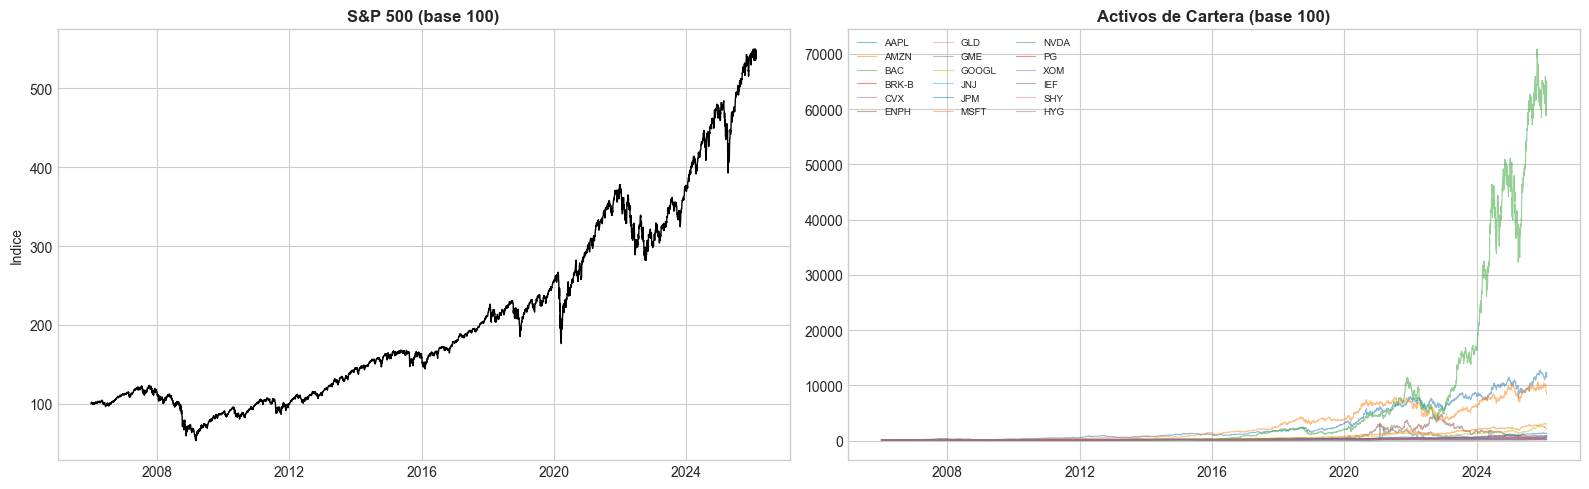

In [7]:
# Visualizacion rapida de precios normalizados (base 100)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel izquierdo: S&P 500
sp = prices[MARKET_TICKER]
axes[0].plot(sp.index, sp / sp.iloc[0] * 100, color='black', linewidth=1)
axes[0].set_title('S&P 500 (base 100)', fontweight='bold')
axes[0].set_ylabel('Indice')

# Panel derecho: todos los activos normalizados
norm = prices[TICKERS].div(prices[TICKERS].iloc[0]) * 100
for col in norm.columns:
    axes[1].plot(norm.index, norm[col], alpha=0.5, linewidth=0.8, label=col)
axes[1].set_title('Activos de Cartera (base 100)', fontweight='bold')
axes[1].legend(ncol=3, fontsize=7, loc='upper left')
plt.tight_layout()
plt.show()


### Visualizacion de Precios Normalizados

**(&P 500:** Se observa la tendencia alcista a largo plazo del mercado americano, con caidas pronunciadas en los periodos de crisis (2020 COVID, 2022 estanflacion) seguidas de recuperaciones. El indice ha multiplicado su valor por ~5x desde 2012.

**Activos de Cartera:** La normalizacion a base 100 revela la enorme dispersion de rendimientos entre activos. Destaca `NVDA`, cuya revalorizacion extrema (>500x) distorsiona visualmente la escala e impide apreciar el comportamiento del resto de activos. Tambien se aprecia que los activos defensivos (`GLD`, `IEF`, `SHY`) se mantienen planos en comparacion con la renta variable, confirmando su menor riesgo pero tambien menor rentabilidad a largo plazo.

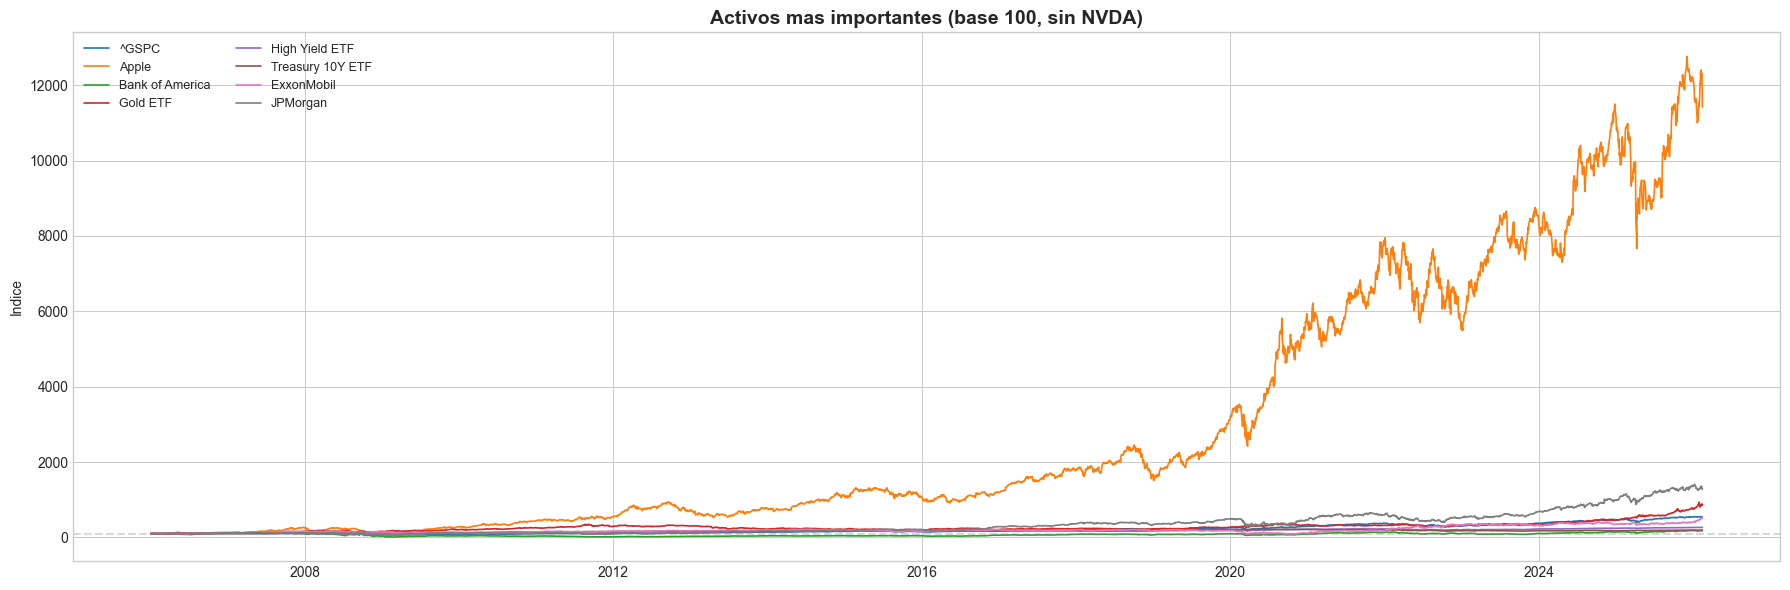

In [8]:
# Activos mas importantes (omitida NVDA para mejor escala)
importantes = ['^GSPC', 'AAPL', 'BAC', 'GLD', 'HYG', 'IEF', 'XOM', 'JPM']
norm_rep = prices[importantes].div(prices[importantes].iloc[0]) * 100

fig, ax = plt.subplots(figsize=(18, 6))
for col in norm_rep.columns:
    label = PORTFOLIO_TICKERS.get(col, col)
    ax.plot(norm_rep.index, norm_rep[col], linewidth=1.2, label=label)

ax.set_title('Activos mas importantes (base 100, sin NVDA)', fontsize=14, fontweight='bold')
ax.set_ylabel('Indice')
ax.legend(ncol=2, fontsize=9)
ax.axhline(100, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Evolucion de Activos Representativos

Al excluir NVDA de la visualizacion, se aprecia con mayor claridad la dinamica de cada clase de activo:

*   **Tecnologia (AAPL):** Lider en rentabilidad acumulada (~15x), con caidas pronunciadas en 2020 y 2022 seguidas de recuperaciones rapidas.
*   **Banca (BAC, JPM):** Trayectorias correlacionadas entre si, con fuerte sensibilidad al ciclo economico. Se observa estancamiento en 2012-2016 y aceleracion posterior.
*   **Energia (XOM):** Comportamiento ciclico ligado al precio del petroleo, con una decada plana (2012-2020) y fuerte repunte tras la estanflacion de 2022.
*   **Oro (GLD):** Crecimiento lento y estable (~2x en 14 anos), con picos en periodos de incertidumbre. Baja correlacion visual con el resto de activos.
*   **Bonos soberanos (IEF):** Practicamente plano, confirmando su rol de estabilizador pero no de generador de rentabilidad. Caida visible en 2022 por las subidas de tipos.
*   **High Yield (HYG):** Estancado en torno a base 100, reflejando que su rentabilidad proviene del cupon (no del precio), con caidas en cada crisis que erosionan el capital.

Esta heterogeneidad justifica el analisis por regimenes: en calma, cada activo sigue su propia logica; en crisis, las correlaciones aumentan y la diversificacion se debilita.

In [9]:
# Retornos logaritmicos diarios
returns = np.log(prices / prices.shift(1)).dropna()  # log(Pt/Pt-1)
print(f"Retornos: {len(returns)} observaciones")

# Resumen anualizado
summary = pd.DataFrame({
    'Media (% anual)': returns.mean() * 252 * 100,
    'Vol (% anual)': returns.std() * np.sqrt(252) * 100,
    'Skewness': returns.apply(skew),
    'Kurtosis': returns.apply(kurtosis)
}).round(2)
display(summary)


Retornos: 5060 observaciones


,Media (% anual),Vol (% anual),Skewness,Kurtosis
Ticker,,,,
AAPL,23.60,31.75,-0.22,6.54
AMZN,22.04,37.53,0.41,12.28
BAC,2.68,46.49,-0.33,26.10
BRK-B,10.59,21.30,0.39,14.60
CVX,9.47,28.54,-0.53,21.53
ENPH,9.00,68.14,-0.19,12.04
GLD,10.78,18.22,-0.45,7.07
GME,10.76,81.82,0.89,69.05
GOOGL,16.64,29.82,0.20,7.84


### Interpretacion de los datos

El bloque de sanity check confirma que la base diaria es consistente: sin indices duplicados, cobertura temporal extensa (desde 2006) y trazabilidad de fuentes por bloque de riesgo. En los activos con huecos historicos se aplico backfill economico con proxies liquidos (ENPH~XLK, HYG~LQD), preservando la informacion de periodos clave como 2008.

Tras la limpieza (forward fill de gaps puntuales y recorte de filas incompletas), la muestra final mantiene los principales ciclos de mercado: crisis financiera global, deuda europea, COVID-19 y estanflacion 2022. Esto permite calibrar transiciones de regimen sobre un historial suficientemente heterogeneo.

La tabla de estadisticas descriptivas muestra que la mayoria de activos de riesgo presentan **kurtosis positiva** y **sesgo negativo**, alejandose de la normalidad. Este comportamiento justifica un enfoque con cambios de regimen, marginales no gaussianas y dependencia de cola.

---
## Fase 1: Detectando el "Pulso" del Mercado (Hidden Markov Models)

### Construccion del vector de features para el HMM

La deteccion de regimenes se modela como un problema multivariable de riesgo sistemico. La meta es identificar estados de estres cuando varias dimensiones se deterioran de forma conjunta, evitando depender de una sola senal.

| Bloque de riesgo | Variable | Proxy operativo | Razon financiera |
| :--- | :--- | :--- | :--- |
| Mercado | `ret_mkt` | Log-return diario del S&P 500 | Resume el tono direccional agregado de renta variable |
| Volatilidad realizada | `vol21_mkt` | Std rolling 21 dias del S&P 500 | Captura aceleracion de riesgo observado |
| Volatilidad implicita | `dlog_vix` | Cambio logaritmico diario del VIX | Mide shocks de aversion al riesgo anticipada |
| Tipos cortos | `dy2` | Cambio diario del tramo corto (proxy 5Y/SHY) | Refleja tension monetaria en la parte corta de la curva |
| Tipos largos | `dy10` | Cambio diario del tramo largo (10Y/IEF) | Refleja shocks de descuento y duracion |
| Pendiente de curva (nivel) | `slope_10_2` | Diferencial de pendientes o proxy equivalente | Diferencia entre fases de endurecimiento y relajacion |
| Credito | `dcs` | Shock diario del spread HY vs soberano | Cuantifica ampliacion de primas de riesgo de credito |
| USD broad | `dlog_usd_broad` | Cambio logaritmico de indice USD (DXY/UUP) | Mide estres de financiacion global en dolares |
| Liquidez | `liq_factor` | Factor cross-sectional de downside y dispersion | Aproxima friccion de ejecucion y venta forzada |
| Volatility Risk Premium | `vrp_proxy` | Vol implicita anualizada menos vol realizada anualizada | Captura prima de incertidumbre y precio de cobertura |

Antes del ajuste del HMM, todas las series se alinean en frecuencia diaria y se estandarizan por z-score para evitar dominancia por escala.

In [10]:
# Construir features multidimensionales para el HMM

def safe_download_close_series(ticker: str, start_date: str, end_date: str):
    """Descarga robusta de serie de cierre para un ticker (si existe)."""
    try:
        raw_dl = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=True)
        if raw_dl is None or len(raw_dl) == 0:
            return None

        if isinstance(raw_dl.columns, pd.MultiIndex):
            if "Close" in raw_dl.columns.get_level_values(0):
                close_obj = raw_dl["Close"]
                if isinstance(close_obj, pd.DataFrame):
                    if ticker in close_obj.columns:
                        s = close_obj[ticker]
                    else:
                        s = close_obj.iloc[:, 0]
                else:
                    s = close_obj
            else:
                s = raw_dl.iloc[:, 0]
        else:
            if "Close" in raw_dl.columns:
                s = raw_dl["Close"]
            else:
                s = raw_dl.iloc[:, 0]

        s = pd.to_numeric(s, errors="coerce")
        return s
    except Exception:
        return None


hmm_features = pd.DataFrame(index=returns.index)

# 1) Mercado: retorno diario del S&P 500
hmm_features["ret_mkt"] = returns[MARKET_TICKER]

# 2) Volatilidad realizada: rolling 21 dias (aprox. 1 mes habil)
hmm_features["vol21_mkt"] = returns[MARKET_TICKER].rolling(21).std()

# 3) Tipos: dy10 y pendiente de curva en nivel (slope_10_2)
if "^TNX" in yields_df.columns:
    y10 = yields_df["^TNX"].reindex(returns.index).ffill()
    hmm_features["dy10"] = y10.diff()
else:
    y10 = None
    hmm_features["dy10"] = -returns["IEF"] * 100
    print("AVISO: Usando IEF como proxy del shock de tipos (10Y no disponible).")

if "^TNX" in yields_df.columns and "^FVX" in yields_df.columns:
    y5 = yields_df["^FVX"].reindex(returns.index).ffill()
    hmm_features["slope_10_2"] = (y10 - y5)
else:
    hmm_features["slope_10_2"] = (returns["IEF"] - returns["SHY"]).rolling(21).mean() * 100
    print("AVISO: Usando spread rolling IEF-SHY como proxy de slope_10_2.")

# 4) Credito: shock diario de spread (dcs)
spread_proxy = returns["HYG"] - returns["IEF"]
hmm_features["dcs"] = -spread_proxy * 100  # positivo = widening de spread

# 5) Liquidez: factor cross-sectional de downside y dispersion
risk_assets = [
    "AAPL", "AMZN", "BAC", "BRK-B", "CVX", "ENPH", "GME", "GOOGL", "JPM", "MSFT", "NVDA", "XOM",
]
risk_assets = [c for c in risk_assets if c in returns.columns]
if len(risk_assets) > 0:
    downside = returns[risk_assets].clip(upper=0)
    hmm_features["liq_factor"] = -downside.mean(axis=1) + downside.std(axis=1)
else:
    hmm_features["liq_factor"] = np.nan
    print("AVISO: no hay activos suficientes para calcular liq_factor.")

# 6) VIX: priorizar VIX real; si no, usar proxy
if "^VIX" in prices.columns:
    vix_series = prices["^VIX"].reindex(returns.index).ffill()
    hmm_features["dlog_vix"] = np.log(vix_series.replace(0.0, np.nan)).diff()
else:
    vix_series = safe_download_close_series("^VIX", START_DATE, END_DATE)
    if vix_series is not None and vix_series.notna().sum() > 0:
        vix_series = vix_series.reindex(returns.index).ffill()
        hmm_features["dlog_vix"] = np.log(vix_series.replace(0.0, np.nan)).diff()
        print("INFO: Usando VIX descargado directamente (^VIX).")
    else:
        vol_proxy = hmm_features["vol21_mkt"].replace(0.0, np.nan)
        hmm_features["dlog_vix"] = np.log(vol_proxy).diff()
        print("AVISO: Usando proxy de volatilidad realizada para dlog_vix (VIX no disponible).")

# 7) dy2: shock de la parte corta de tipos (o proxy)
if "^IRX" in yields_df.columns:
    y2 = yields_df["^IRX"].reindex(returns.index).ffill()
    hmm_features["dy2"] = y2.diff()
elif "^FVX" in yields_df.columns:
    y2_proxy = yields_df["^FVX"].reindex(returns.index).ffill()
    hmm_features["dy2"] = y2_proxy.diff()
    print("AVISO: Usando ^FVX como proxy de dy2 (2Y no disponible).")
elif "SHY" in returns.columns:
    hmm_features["dy2"] = returns["SHY"].diff() * 100
    print("AVISO: Usando SHY como proxy de dy2.")
else:
    hmm_features["dy2"] = np.nan
    print("AVISO: dy2 no disponible; se marca como NaN para excluirlo del ajuste.")

# 8) USD broad: cambio logaritmico diario (o proxy)
if "DTWEXBGS" in prices.columns:
    usd_series = prices["DTWEXBGS"].reindex(returns.index).ffill()
    hmm_features["dlog_usd_broad"] = np.log(usd_series.replace(0.0, np.nan)).diff()
else:
    dxy_series = None
    if "DX-Y.NYB" in prices.columns:
        dxy_series = prices["DX-Y.NYB"].reindex(returns.index).ffill()
    else:
        dxy_dl = safe_download_close_series("DX-Y.NYB", START_DATE, END_DATE)
        if dxy_dl is not None and dxy_dl.notna().sum() > 0:
            dxy_series = dxy_dl.reindex(returns.index).ffill()

    if dxy_series is not None and dxy_series.notna().sum() > 0:
        hmm_features["dlog_usd_broad"] = np.log(dxy_series.replace(0.0, np.nan)).diff()
        print("AVISO: Usando DXY (DX-Y.NYB) como proxy de USD broad.")
    else:
        uup_series = None
        if "UUP" in prices.columns:
            uup_series = prices["UUP"].reindex(returns.index).ffill()
        else:
            uup_dl = safe_download_close_series("UUP", START_DATE, END_DATE)
            if uup_dl is not None and uup_dl.notna().sum() > 0:
                uup_series = uup_dl.reindex(returns.index).ffill()

        if uup_series is not None and uup_series.notna().sum() > 0:
            hmm_features["dlog_usd_broad"] = np.log(uup_series.replace(0.0, np.nan)).diff()
            print("AVISO: Usando UUP como proxy de USD broad.")
        elif "UUP" in returns.columns:
            hmm_features["dlog_usd_broad"] = returns["UUP"]
            print("AVISO: Usando retorno de UUP como proxy de dlog_usd_broad.")
        else:
            hmm_features["dlog_usd_broad"] = np.nan
            print("AVISO: USD broad no disponible; se marca como NaN para excluirlo del ajuste.")

# 9) VRP proxy: volatilidad implicita anualizada menos volatilidad realizada anualizada
if vix_series is not None and vix_series.notna().sum() > 0:
    iv_ann = vix_series.reindex(returns.index).ffill() / 100.0
    rv_ann = hmm_features["vol21_mkt"] * np.sqrt(252)
    hmm_features["vrp_proxy"] = iv_ann - rv_ann
else:
    hmm_features["vrp_proxy"] = np.nan
    print("AVISO: VRP no disponible por falta de VIX.")

feature_order = [
    "ret_mkt",
    "vol21_mkt",
    "dlog_vix",
    "dy2",
    "dy10",
    "slope_10_2",
    "dcs",
    "dlog_usd_broad",
    "liq_factor",
    "vrp_proxy",
]
hmm_features = hmm_features[[c for c in feature_order if c in hmm_features.columns]]

# Limpiar features: primero columnas vacias, luego filas con NaN remanente
empty_cols = [c for c in hmm_features.columns if hmm_features[c].notna().sum() == 0]
if len(empty_cols) > 0:
    print(f"AVISO: Se eliminan columnas sin datos validos: {empty_cols}")
    hmm_features = hmm_features.drop(columns=empty_cols)

hmm_features = hmm_features.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Features HMM usadas ({hmm_features.shape[1]}): {list(hmm_features.columns)}")
print(f"Observaciones validas para HMM: {len(hmm_features)} dias")
display(hmm_features.describe().round(4))

INFO: Usando VIX descargado directamente (^VIX).
AVISO: Usando ^FVX como proxy de dy2 (2Y no disponible).
AVISO: Usando DXY (DX-Y.NYB) como proxy de USD broad.
Features HMM usadas (10): ['ret_mkt', 'vol21_mkt', 'dlog_vix', 'dy2', 'dy10', 'slope_10_2', 'dcs', 'dlog_usd_broad', 'liq_factor', 'vrp_proxy']
Observaciones validas para HMM: 5040 dias


,ret_mkt,vol21_mkt,dlog_vix,dy2,dy10,slope_10_2,dcs,dlog_usd_broad,liq_factor,vrp_proxy
count,5040.0000,5040.0000,5040.0000,5040.0000,5040.0000,5040.0000,5040.0000,5040.0000,5040.0000,5040.0000
mean,0.0003,0.0101,0.0001,-0.0002,-0.0001,0.5477,-0.0059,0.0000,0.0179,0.0340
std,0.0123,0.0071,0.0767,0.0587,0.0570,0.4548,0.8318,0.0047,0.0196,0.0551
min,-0.1277,0.0022,-0.4424,-0.4580,-0.4700,-0.3600,-12.2592,-0.0272,0.0000,-0.5232
25%,-0.0041,0.0059,-0.0424,-0.0310,-0.0330,0.1630,-0.3403,-0.0026,0.0058,0.0153
50%,0.0007,0.0083,-0.0062,0.0000,-0.0010,0.4745,-0.0262,0.0000,0.0128,0.0388
75%,0.0058,0.0120,0.0347,0.0300,0.0330,0.9880,0.2979,0.0026,0.0236,0.0613
max,0.1096,0.0615,0.7682,0.4860,0.3320,1.4980,9.8292,0.0252,0.3409,0.2440


### Estadisticas Descriptivas de las Variables de Estado

La deteccion de regimenes se apoya en una canasta de factores con lectura economica directa y no redundante:

* **Mercado (`ret_mkt`)**: retorno diario del S&P 500 como pulso agregado de riesgo direccional.
* **Volatilidad (`vol21_mkt`, `dlog_vix`)**: combinacion de riesgo realizado e implicito para capturar cambios de incertidumbre observada y anticipada.
* **Tipos (`dy2`, `dy10`, `slope_10_2`)**: shocks de curva y pendiente en nivel para reflejar tension monetaria y de descuento.
* **Credito (`dcs`)**: widening diario del spread HY vs soberano como indicador de deterioro de calidad crediticia.
* **Liquidez (`liq_factor`)**: tension de ejecucion aproximada por downside cross-sectional y dispersion de retornos negativos.
* **Prima de volatilidad (`vrp_proxy`)**: diferencia entre volatilidad implicita y realizada, como señal de demanda de cobertura y aversion al riesgo.
* **USD broad (`dlog_usd_broad`)**: shock de dolar amplio para capturar estres de financiacion global.

Con esta construccion, el estado de crisis se interpreta como deterioro simultaneo de volatilidad, credito, liquidez, curva de tipos y prima de incertidumbre, en lugar de depender de una unica variable.

In [11]:
# Estandarizar features antes de ajustar el HMM
# Se usa z-score para que ninguna variable domine por escala.
def zscore_df(df: pd.DataFrame) -> pd.DataFrame:
    work = df.replace([np.inf, -np.inf], np.nan).copy()

    # Quitar columnas completamente vacias
    non_empty_cols = [c for c in work.columns if work[c].notna().sum() > 0]
    work = work[non_empty_cols]

    mu = work.mean(axis=0)
    sd = work.std(axis=0, ddof=0)

    # Si una columna no tiene varianza, se excluye del ajuste en lugar de vaciar todo X
    valid_cols = [c for c in work.columns if np.isfinite(sd[c]) and sd[c] > 0 and np.isfinite(mu[c])]
    dropped_cols = [c for c in work.columns if c not in valid_cols]
    if len(dropped_cols) > 0:
        print(f"AVISO: Columnas excluidas del HMM por varianza nula/sin datos: {dropped_cols}")

    z = (work[valid_cols] - mu[valid_cols]) / sd[valid_cols]
    z = z.replace([np.inf, -np.inf], np.nan).dropna()

    if len(z) == 0:
        raise ValueError(
            "No hay observaciones validas para el HMM tras estandarizar. "
            "Revisa factores con NaN/constantes en hmm_features."
        )

    return z


hmm_z = zscore_df(hmm_features)
X = hmm_z.values

# Modelo base (referencia) para comparar log-likelihood
def fit_base_hmm(X: np.ndarray, seed: int = SEED, covariance_type: str = "diag"):
    m = GaussianHMM(
        n_components=2,
        covariance_type=covariance_type,
        n_iter=250,
        random_state=seed,
        tol=1e-4,
        min_covar=1e-4,
    )
    m.fit(X)
    return m, float(m.score(X))


# Modelo robusto con persistencia (sticky) y multiples reinicios
# Nota: se mantiene SIEMPRE n_components=2 (Calma/Crisis).
def fit_sticky_hmm(
    X: np.ndarray,
    n_components: int = 2,
    n_inits: int = 10,
    diag_strength: float = 4000.0,
    off_strength: float = 1.0,
    init_self_p: float = 0.992,
    n_iter: int = 600,
    tol: float = 1e-4,
    min_covar: float = 1e-4,
    base_seed: int = 100,
    covariance_type: str = "diag",
):
    if n_components != 2:
        raise ValueError("Este notebook fija n_components=2 por diseno (calma/crisis).")

    best = {"ll": -np.inf, "model": None}

    transmat_prior = np.full((n_components, n_components), off_strength, dtype=float)
    np.fill_diagonal(transmat_prior, diag_strength)

    trans0 = np.full((n_components, n_components), (1.0 - init_self_p) / (n_components - 1), dtype=float)
    np.fill_diagonal(trans0, init_self_p)
    start0 = np.full(n_components, 1.0 / n_components, dtype=float)

    for k in range(n_inits):
        seed = base_seed + k
        m = GaussianHMM(
            n_components=n_components,
            covariance_type=covariance_type,
            n_iter=n_iter,
            tol=tol,
            random_state=seed,
            algorithm="map",
            min_covar=min_covar,
            transmat_prior=transmat_prior,
        )

        m.init_params = "mc"   # inicializa solo medias/covarianzas
        m.params = "stmc"      # reestima todo con prior de transicion
        m.startprob_ = start0.copy()
        m.transmat_ = trans0.copy()

        m.fit(X)
        ll = float(m.score(X))
        if ll > best["ll"]:
            best = {"ll": ll, "model": m}

    return best["model"], best["ll"]


base_model, ll_base = fit_base_hmm(X, covariance_type="diag")
model, ll_sticky = fit_sticky_hmm(X, covariance_type="diag")

raw_states = model.predict(X)
p_states = model.predict_proba(X)

print("HMM ajustado con configuracion robusta (sticky + multi-start, 2 estados).")
print(f"LogLik base={ll_base:,.1f} | LogLik sticky(diag)={ll_sticky:,.1f}")
print(f"Estado 0: {(raw_states == 0).sum()} dias | Estado 1: {(raw_states == 1).sum()} dias")

Model is not converging.  Current: -61256.629910036696 is not greater than -61256.429984217735. Delta is -0.19992581896076445
Model is not converging.  Current: -61256.62910947932 is not greater than -61256.42975542241. Delta is -0.1993540569092147
Model is not converging.  Current: -61256.629910036696 is not greater than -61256.429984217735. Delta is -0.19992581896076445
Model is not converging.  Current: -61256.62386228254 is not greater than -61256.43017793437. Delta is -0.19368434816715308
Model is not converging.  Current: -61256.62991025138 is not greater than -61256.42998522339. Delta is -0.1999250279914122
Model is not converging.  Current: -61256.61483457027 is not greater than -61256.43314673584. Delta is -0.18168783442524727
Model is not converging.  Current: -61256.61297328037 is not greater than -61256.433063843004. Delta is -0.17990943736367626
Model is not converging.  Current: -61256.62991025138 is not greater than -61256.42998522339. Delta is -0.1999250279914122
Model 

HMM ajustado con configuracion robusta (sticky + multi-start, 2 estados).
LogLik base=-60,921.4 | LogLik sticky(diag)=-61,256.9
Estado 0: 3591 dias | Estado 1: 1449 dias


El HMM se estima con una configuracion robusta (persistencia en transiciones + multiples reinicios), lo que reduce cambios espurios y mejora estabilidad temporal.

La asignacion final de etiquetas se realiza con un **score economico de estres** que combina bloques de volatilidad (`vol21_mkt`, `dlog_vix`, `vrp_proxy`), credito (`dcs`), liquidez (`liq_factor`), tipos (`dy2`, `dy10`, `slope_10_2`) y dolar (`dlog_usd_broad`). Asi, la etiqueta "Crisis" representa un deterioro financiero interpretable y no solo una clase numerica del algoritmo.

In [12]:
# Identificar estado de crisis con score economico (no solo por volatilidad)
def wmean(x: np.ndarray, w: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    m = np.isfinite(x) & np.isfinite(w)
    if m.sum() == 0:
        return np.nan
    ww = w[m]
    den = ww.sum()
    if den <= 0:
        return np.nan
    return float(np.sum(x[m] * ww) / den)


def state_signal_mu(df: pd.DataFrame, col: str, w: np.ndarray) -> float:
    if col not in df.columns:
        return np.nan
    return wmean(df[col].values, w)


state_scores = []
state_components = []
for k in range(2):
    wk = p_states[:, k]

    vol_mu = state_signal_mu(hmm_features, "vol21_mkt", wk)
    credit_mu = state_signal_mu(hmm_features, "dcs", wk)
    liq_mu = state_signal_mu(hmm_features, "liq_factor", wk)

    dy2_mu = state_signal_mu(hmm_features, "dy2", wk)
    dy10_mu = state_signal_mu(hmm_features, "dy10", wk)
    slope_mu = state_signal_mu(hmm_features, "slope_10_2", wk)

    vix_mu = state_signal_mu(hmm_features, "dlog_vix", wk)
    usd_mu = state_signal_mu(hmm_features, "dlog_usd_broad", wk)
    vrp_mu = state_signal_mu(hmm_features, "vrp_proxy", wk)

    # En estres esperamos valores altos para volatilidad/credito/liquidez/VIX/USD/VRP
    vol_score = max(vol_mu, 0.0) if np.isfinite(vol_mu) else 0.0
    credit_score = max(credit_mu, 0.0) if np.isfinite(credit_mu) else 0.0
    liq_score = max(liq_mu, 0.0) if np.isfinite(liq_mu) else 0.0
    vix_score = max(vix_mu, 0.0) if np.isfinite(vix_mu) else 0.0
    usd_score = max(usd_mu, 0.0) if np.isfinite(usd_mu) else 0.0
    vrp_score = max(vrp_mu, 0.0) if np.isfinite(vrp_mu) else 0.0

    # En tipos usamos magnitud absoluta de shocks y pendiente
    rates_score = 0.0
    if np.isfinite(dy2_mu):
        rates_score += abs(dy2_mu)
    if np.isfinite(dy10_mu):
        rates_score += abs(dy10_mu)
    if np.isfinite(slope_mu):
        rates_score += abs(slope_mu)

    total_score = (
        vol_score
        + credit_score
        + liq_score
        + 0.75 * rates_score
        + 0.50 * vix_score
        + 0.30 * usd_score
        + 0.35 * vrp_score
    )

    state_scores.append(total_score)
    state_components.append(
        {
            "state": k,
            "vol": vol_score,
            "credit": credit_score,
            "liq": liq_score,
            "rates": rates_score,
            "vix": vix_score,
            "usd": usd_score,
            "vrp": vrp_score,
            "total": total_score,
        }
    )

stress_state = int(np.argmax(state_scores))

# Reordenar para mantener convencion: 0=Calma, 1=Crisis
if stress_state == 0:
    raw_states = 1 - raw_states
    p_states = p_states[:, ::-1]
    model.means_ = model.means_[::-1]
    model.covars_ = model.covars_[::-1]
    model.transmat_ = model.transmat_[::-1, ::-1]
    model.startprob_ = model.startprob_[::-1]

# Probabilidad diaria de crisis (senal "soft")
p_stress = p_states[:, 1]

print("Asignacion final: Estado 0 = Calma | Estado 1 = Crisis")
print("Score ponderado = base + 0.75*rates + 0.50*VIX + 0.30*USD + 0.35*VRP")
print(f"Score estado 0: {state_scores[1 if stress_state == 0 else 0]:.4f}")
print(f"Score estado 1: {state_scores[stress_state]:.4f}")
print(f"Vol media calma:  {hmm_features['vol21_mkt'].values[raw_states == 0].mean():.4f}")
print(f"Vol media crisis: {hmm_features['vol21_mkt'].values[raw_states == 1].mean():.4f}")
print(f"p_stress media: {np.mean(p_stress):.3f}")
display(pd.DataFrame(state_components).set_index("state").round(4))

Asignacion final: Estado 0 = Calma | Estado 1 = Crisis
Score ponderado = base + 0.75*rates + 0.50*VIX + 0.30*USD + 0.35*VRP
Score estado 0: 0.4419
Score estado 1: 0.5753
Vol media calma:  0.0073
Vol media crisis: 0.0172
p_stress media: 0.289


,vol,credit,liq,rates,vix,usd,vrp,total
state,,,,,,,,
0,0.0073,0.0000,0.0136,0.5408,0.0000,0.0000,0.0439,0.4419
1,0.0172,0.0838,0.0286,0.5824,0.0111,0.0002,0.0095,0.5753


In [13]:
# Filtrado robusto de episodios: histÃƒÂ©resis + fusion de gaps + duracion minima
MIN_CRISIS_DAYS = 30
ENTER_THR = 0.75
EXIT_THR = 0.35
MAX_GAP_DAYS = 10


def hysteresis_binary(p: np.ndarray, enter_thr: float = 0.7, exit_thr: float = 0.3) -> np.ndarray:
    p = np.asarray(p, dtype=float)
    y = np.zeros_like(p, dtype=int)
    in_stress = False
    for t, pt in enumerate(p):
        if not in_stress and pt >= enter_thr:
            in_stress = True
        elif in_stress and pt <= exit_thr:
            in_stress = False
        y[t] = 1 if in_stress else 0
    return y


def remove_short_runs(binary: np.ndarray, min_len: int) -> np.ndarray:
    x = np.asarray(binary, dtype=int)
    if len(x) == 0:
        return x
    change = np.r_[True, x[1:] != x[:-1]]
    starts = np.where(change)[0]
    ends = np.r_[starts[1:] - 1, len(x) - 1]
    out = x.copy()
    for a, b in zip(starts, ends):
        if x[a] == 1 and (b - a + 1) < min_len:
            out[a:b + 1] = 0
    return out


def merge_close_runs_once(binary: np.ndarray, max_gap: int) -> np.ndarray:
    x = np.asarray(binary, dtype=int)
    if len(x) == 0:
        return x
    change = np.r_[True, x[1:] != x[:-1]]
    starts = np.where(change)[0]
    ends = np.r_[starts[1:] - 1, len(x) - 1]
    out = x.copy()

    for i in range(len(starts) - 2):
        a1, b1 = starts[i], ends[i]
        a0, b0 = starts[i + 1], ends[i + 1]
        a2, b2 = starts[i + 2], ends[i + 2]
        if x[a1] == 1 and x[a0] == 0 and x[a2] == 1 and (b0 - a0 + 1) <= max_gap:
            out[a0:b0 + 1] = 1
    return out


def merge_close_runs(binary: np.ndarray, max_gap: int, max_iters: int = 10) -> np.ndarray:
    out = np.asarray(binary, dtype=int)
    for _ in range(max_iters):
        new = merge_close_runs_once(out, max_gap=max_gap)
        if np.array_equal(new, out):
            break
        out = new
    return out


def state_runs(states_arr: np.ndarray, dates: pd.DatetimeIndex) -> pd.DataFrame:
    s = np.asarray(states_arr, dtype=int)
    if len(s) != len(dates):
        raise ValueError("states y dates deben tener la misma longitud")
    if len(s) == 0:
        return pd.DataFrame(columns=["state", "start", "end", "n_days"])

    change = np.r_[True, s[1:] != s[:-1]]
    starts = np.where(change)[0]
    ends = np.r_[starts[1:] - 1, len(s) - 1]

    rows = []
    for a, b in zip(starts, ends):
        rows.append({
            "state": int(s[a]),
            "start": dates[a],
            "end": dates[b],
            "n_days": int(b - a + 1),
        })
    return pd.DataFrame(rows)


# Pipeline de crisis financiero-economicamente interpretable
raw_stress = hysteresis_binary(p_stress, enter_thr=ENTER_THR, exit_thr=EXIT_THR)
stress_merged = merge_close_runs(raw_stress, max_gap=MAX_GAP_DAYS)
states = remove_short_runs(stress_merged, min_len=MIN_CRISIS_DAYS)

n_filtered = int((raw_states != states).sum())
print(f"Filtro aplicado: {n_filtered} dias reclasificados respecto a Viterbi bruto")
print(f"Parametros: enter={ENTER_THR:.2f}, exit={EXIT_THR:.2f}, min_len={MIN_CRISIS_DAYS}, max_gap={MAX_GAP_DAYS}")
print(f"Final: Calma={(states == 0).sum()} dias ({(states == 0).mean():.1%}) | Crisis={(states == 1).sum()} dias ({(states == 1).mean():.1%})")

Filtro aplicado: 561 dias reclasificados respecto a Viterbi bruto
Parametros: enter=0.75, exit=0.35, min_len=30, max_gap=10
Final: Calma=3600 dias (71.4%) | Crisis=1440 dias (28.6%)


In [14]:
# Alinear estados con retornos (mismo rango temporal)
returns = returns.loc[hmm_features.index].copy()
returns["State"] = states
returns["p_stress"] = p_stress


def estimate_transmat(states_arr: np.ndarray, alpha: float = 1.0) -> tuple[np.ndarray, np.ndarray]:
    """Matriz de transicion empirica con suavizado de Laplace."""
    s = np.asarray(states_arr, dtype=int)
    counts = np.full((2, 2), alpha, dtype=float)
    for t in range(1, len(s)):
        counts[s[t - 1], s[t]] += 1
    probs = counts / counts.sum(axis=1, keepdims=True)
    return probs, counts


transmat_emp, trans_counts = estimate_transmat(states, alpha=1.0)
TRANSMAT_SIM = transmat_emp.copy()  # matriz usada por el motor de simulacion

trans_df = pd.DataFrame(
    TRANSMAT_SIM,
    index=["Desde Calma", "Desde Crisis"],
    columns=["Hacia Calma", "Hacia Crisis"],
)
display(trans_df.round(4))

# Duraciones esperadas por estado segun la matriz final usada en simulacion
dur_calma = 1.0 / max(1e-12, TRANSMAT_SIM[0, 1])
dur_crisis = 1.0 / max(1e-12, TRANSMAT_SIM[1, 0])
print(f"Duracion esperada: Calma ~{dur_calma:.0f} dias | Crisis ~{dur_crisis:.0f} dias")
print("(Matriz estimada sobre estados filtrados para mantener coherencia financiera.)")

,Hacia Calma,Hacia Crisis
Desde Calma,0.9958,0.0042
Desde Crisis,0.0104,0.9896


Duracion esperada: Calma ~240 dias | Crisis ~96 dias
(Matriz estimada sobre estados filtrados para mantener coherencia financiera.)


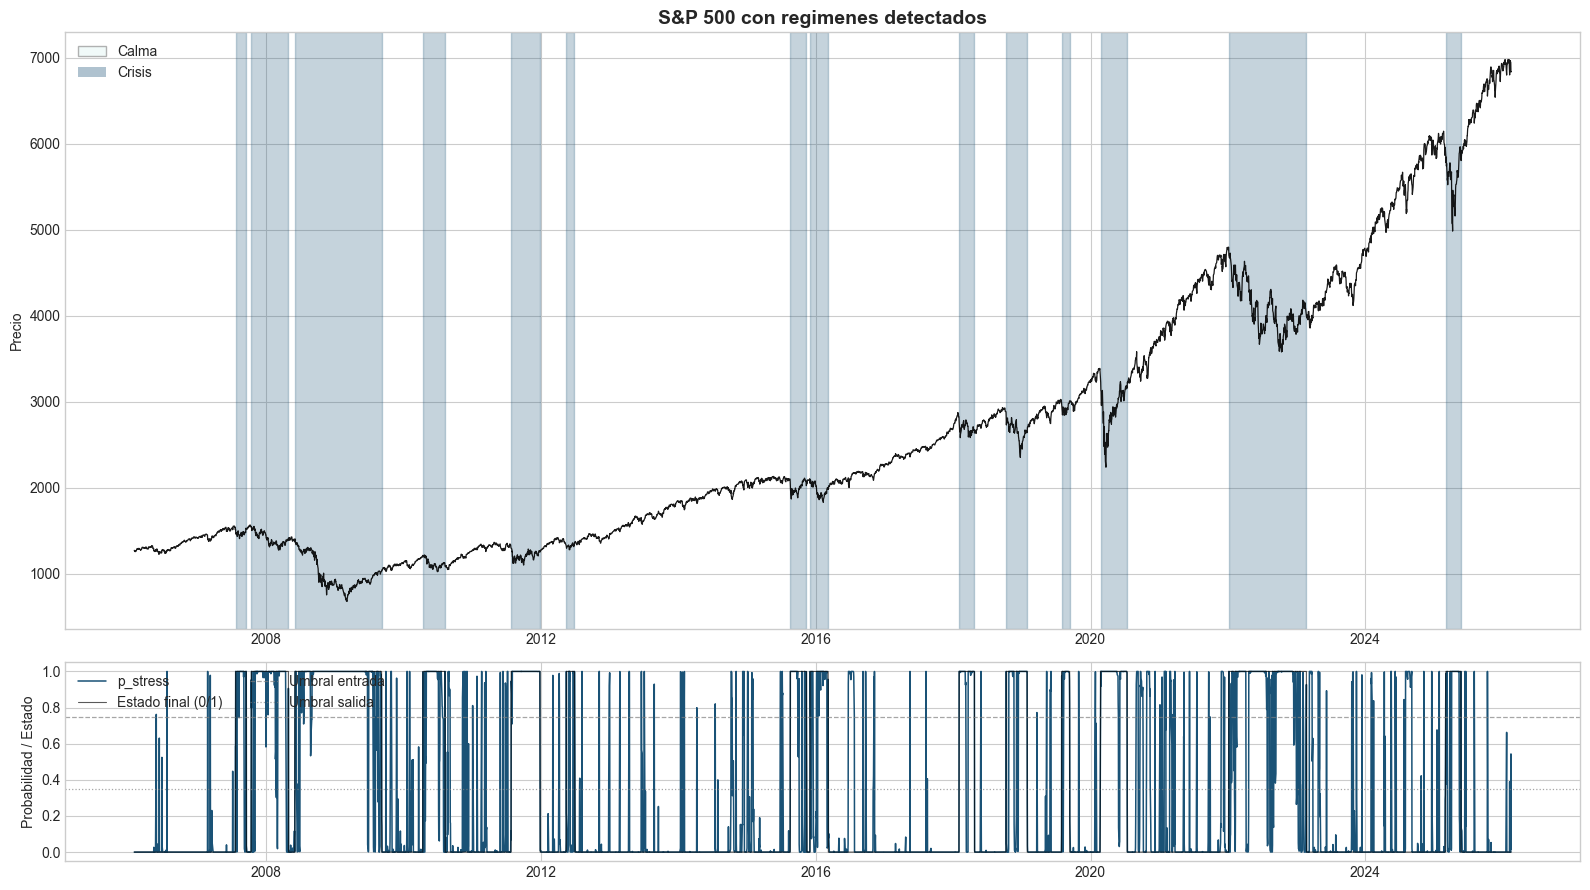

In [15]:
# Grafico de regimenes (enunciado: Blanco=Calma, Azul=Crisis)
price_data = prices[MARKET_TICKER].loc[returns.index]
runs_df = state_runs(states, price_data.index)
periods_stress = runs_df[runs_df["state"] == 1].copy().reset_index(drop=True)
periods_stress["period_id"] = np.arange(1, len(periods_stress) + 1)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), gridspec_kw={"height_ratios": [3, 1]})

# Panel 1: S&P500 + sombreado de episodios de crisis
ax1 = axes[0]
ax1.plot(price_data.index, price_data.values, color="black", linewidth=0.9, alpha=0.9)
for _, r in periods_stress.iterrows():
    ax1.axvspan(r["start"], r["end"], color=COLOR_CRISIS, alpha=0.25)

ax1.set_title("S&P 500 con regimenes detectados", fontsize=14, fontweight="bold")
ax1.set_ylabel("Precio")
ax1.legend(handles=[
    Patch(facecolor=COLOR_CALMA_FILL, edgecolor="gray", alpha=0.6, label="Calma"),
    Patch(facecolor=COLOR_CRISIS, alpha=0.35, label="Crisis"),
], loc="upper left")

# Panel 2: probabilidad diaria de crisis + estado final binario
ax2 = axes[1]
ax2.plot(price_data.index, p_stress, color=COLOR_CRISIS, linewidth=1.1, label="p_stress")
ax2.plot(price_data.index, states, color="black", linewidth=0.8, alpha=0.65, label="Estado final (0/1)")
ax2.axhline(ENTER_THR, color="gray", linestyle="--", linewidth=0.9, alpha=0.7, label="Umbral entrada")
ax2.axhline(EXIT_THR, color="gray", linestyle=":", linewidth=0.9, alpha=0.7, label="Umbral salida")
ax2.set_ylim(-0.05, 1.05)
ax2.set_ylabel("Probabilidad / Estado")
ax2.legend(loc="upper left", ncol=2)

plt.tight_layout()
plt.show()

### Visualizacion de Regimenes Detectados

El grafico superpone episodios de crisis (bandas azules) sobre la serie del S&P 500 y, en el panel inferior, la probabilidad diaria de estres (`p_stress`) junto con el estado binario final.

**Lectura financiera:**
* **Coherencia temporal:** los episodios agregan dias contiguos y evitan cambios de estado espurios de 1-2 dias.
* **Transiciones interpretables:** la entrada/salida de crisis queda gobernada por umbrales asimetricos (histeresis), reproduciendo la inercia real de mercado.
* **Consistencia financiera:** los episodios de estres coinciden con ampliacion de spread de credito, deterioro de liquidez, tension en curva de tipos y repuntes conjuntos de VIX/VRP.

In [16]:
# Benchmark tecnico (2 estados): covariance_type="diag" vs "full"
# Se usa el mismo pipeline de etiquetado economico y postfiltro para comparar de forma consistente.

def economic_scores_from_probs(features_df: pd.DataFrame, probs: np.ndarray) -> list:
    scores = []
    for k in range(2):
        wk = probs[:, k]

        vol_mu = state_signal_mu(features_df, "vol21_mkt", wk)
        credit_mu = state_signal_mu(features_df, "dcs", wk)
        liq_mu = state_signal_mu(features_df, "liq_factor", wk)

        dy2_mu = state_signal_mu(features_df, "dy2", wk)
        dy10_mu = state_signal_mu(features_df, "dy10", wk)
        slope_mu = state_signal_mu(features_df, "slope_10_2", wk)

        vix_mu = state_signal_mu(features_df, "dlog_vix", wk)
        usd_mu = state_signal_mu(features_df, "dlog_usd_broad", wk)
        vrp_mu = state_signal_mu(features_df, "vrp_proxy", wk)

        vol_score = max(vol_mu, 0.0) if np.isfinite(vol_mu) else 0.0
        credit_score = max(credit_mu, 0.0) if np.isfinite(credit_mu) else 0.0
        liq_score = max(liq_mu, 0.0) if np.isfinite(liq_mu) else 0.0
        vix_score = max(vix_mu, 0.0) if np.isfinite(vix_mu) else 0.0
        usd_score = max(usd_mu, 0.0) if np.isfinite(usd_mu) else 0.0
        vrp_score = max(vrp_mu, 0.0) if np.isfinite(vrp_mu) else 0.0

        rates_score = 0.0
        if np.isfinite(dy2_mu):
            rates_score += abs(dy2_mu)
        if np.isfinite(dy10_mu):
            rates_score += abs(dy10_mu)
        if np.isfinite(slope_mu):
            rates_score += abs(slope_mu)

        total_score = (
            vol_score
            + credit_score
            + liq_score
            + 0.75 * rates_score
            + 0.50 * vix_score
            + 0.30 * usd_score
            + 0.35 * vrp_score
        )
        scores.append(total_score)
    return scores


def postfilter_states_binary(
    p_stress_arr: np.ndarray,
    enter_thr: float,
    exit_thr: float,
    min_len: int,
    max_gap: int,
) -> np.ndarray:
    raw = hysteresis_binary(p_stress_arr, enter_thr=enter_thr, exit_thr=exit_thr)
    merged = merge_close_runs(raw, max_gap=max_gap)
    return remove_short_runs(merged, min_len=min_len)


def hmm_param_count(n_features: int, covariance_type: str, n_components: int = 2) -> int:
    # Aproximacion para AIC/BIC del HMM gaussiano (2 estados fijos)
    startprob_params = n_components - 1
    transmat_params = n_components * (n_components - 1)
    mean_params = n_components * n_features
    if covariance_type == "diag":
        cov_params = n_components * n_features
    else:
        cov_params = n_components * (n_features * (n_features + 1) // 2)
    return int(startprob_params + transmat_params + mean_params + cov_params)


returns_bench = returns.loc[hmm_features.index].copy()
benchmark_rows = []
benchmark_states = {}
benchmark_p_stress = {}

for cov_type in ["diag", "full"]:
    cov_model, cov_ll = fit_sticky_hmm(X, covariance_type=cov_type)

    cov_raw_states = cov_model.predict(X)
    cov_p_states = cov_model.predict_proba(X)

    cov_scores = economic_scores_from_probs(hmm_features, cov_p_states)
    cov_stress_state = int(np.argmax(cov_scores))

    if cov_stress_state == 0:
        cov_raw_states = 1 - cov_raw_states
        cov_p_states = cov_p_states[:, ::-1]

    cov_p_stress = cov_p_states[:, 1]
    cov_states = postfilter_states_binary(
        cov_p_stress,
        enter_thr=ENTER_THR,
        exit_thr=EXIT_THR,
        min_len=MIN_CRISIS_DAYS,
        max_gap=MAX_GAP_DAYS,
    )

    benchmark_states[cov_type] = cov_states
    benchmark_p_stress[cov_type] = cov_p_stress

    runs_cov = state_runs(cov_states, hmm_features.index)
    crisis_runs_cov = runs_cov.loc[runs_cov["state"] == 1, "n_days"]

    mask_crisis = cov_states == 1
    mask_calma = cov_states == 0

    vol_crisis = np.nan
    vol_calma = np.nan
    if mask_crisis.sum() > 2:
        vol_crisis = float(returns_bench.loc[mask_crisis, MARKET_TICKER].std() * np.sqrt(252) * 100)
    if mask_calma.sum() > 2:
        vol_calma = float(returns_bench.loc[mask_calma, MARKET_TICKER].std() * np.sqrt(252) * 100)

    n_params = hmm_param_count(X.shape[1], cov_type, n_components=2)
    n_obs = max(len(X), 1)
    aic = 2 * n_params - 2 * cov_ll
    bic = np.log(n_obs) * n_params - 2 * cov_ll

    benchmark_rows.append(
        {
            "covariance_type": cov_type,
            "log_likelihood": cov_ll,
            "AIC": aic,
            "BIC": bic,
            "% dias crisis": float(mask_crisis.mean() * 100),
            "n episodios crisis": int((runs_cov["state"] == 1).sum()),
            "duracion media crisis (dias)": float(crisis_runs_cov.mean()) if len(crisis_runs_cov) else np.nan,
            "vol crisis anualizada (%)": vol_crisis,
            "vol calma anualizada (%)": vol_calma,
            "spread vol crisis-calma": float(vol_crisis - vol_calma) if (np.isfinite(vol_crisis) and np.isfinite(vol_calma)) else np.nan,
        }
    )

benchmark_table = pd.DataFrame(benchmark_rows).set_index("covariance_type").round(3)

recommended_covariance = "diag"
if (
    benchmark_table.loc["full", "BIC"] < benchmark_table.loc["diag", "BIC"]
    and benchmark_table.loc["full", "spread vol crisis-calma"] >= benchmark_table.loc["diag", "spread vol crisis-calma"]
):
    recommended_covariance = "full"

print("BENCHMARK 2 ESTADOS: DIAG VS FULL")
display(benchmark_table)
print(f"Covarianza recomendada (2 estados): {recommended_covariance}")

Model is not converging.  Current: -61256.629910036696 is not greater than -61256.429984217735. Delta is -0.19992581896076445
Model is not converging.  Current: -61256.62910947932 is not greater than -61256.42975542241. Delta is -0.1993540569092147
Model is not converging.  Current: -61256.629910036696 is not greater than -61256.429984217735. Delta is -0.19992581896076445
Model is not converging.  Current: -61256.62386188367 is not greater than -61256.430177284295. Delta is -0.19368459937686566
Model is not converging.  Current: -61256.629910036696 is not greater than -61256.429984217735. Delta is -0.19992581896076445
Model is not converging.  Current: -61256.614834232336 is not greater than -61256.43314779. Delta is -0.18168644233810483
Model is not converging.  Current: -61256.61297328037 is not greater than -61256.433063843004. Delta is -0.17990943736367626
Model is not converging.  Current: -61256.62991025138 is not greater than -61256.42998522339. Delta is -0.1999250279914122
Mode

BENCHMARK 2 ESTADOS: DIAG VS FULL


,log_likelihood,AIC,BIC,% dias crisis,n episodios crisis,duracion media crisis (dias),vol crisis anualizada (%),vol calma anualizada (%),spread vol crisis-calma
covariance_type,,,,,,,,,
diag,-61256.859,122599.718,122880.300,28.571,14,102.857,31.458,11.674,19.784
full,-47976.556,96219.112,97086.958,26.111,13,101.231,32.297,12.102,20.195


Covarianza recomendada (2 estados): full


In [17]:
# Validacion walk-forward (sin fuga temporal) del detector de estados (2 estados)
def walk_forward_detection(
    features_df: pd.DataFrame,
    returns_df: pd.DataFrame,
    train_window: int = 252 * 4,
    test_window: int = 126,
    step_size: int = 63,
    covariance_type: str = "diag",
):
    records = []
    wf_states_all = pd.Series(index=features_df.index, dtype=float)
    wf_p_stress_all = pd.Series(index=features_df.index, dtype=float)

    n_total = len(features_df)
    last_start = n_total - train_window - test_window
    if last_start <= 0:
        return pd.DataFrame(), wf_states_all, wf_p_stress_all

    for start in range(0, last_start + 1, step_size):
        train_slice = slice(start, start + train_window)
        test_slice = slice(start + train_window, start + train_window + test_window)

        train_df = features_df.iloc[train_slice].copy()
        test_df = features_df.iloc[test_slice].copy()
        if len(test_df) == 0:
            continue

        # Estandarizacion estricta con estadisticos de train (evita leakage)
        mu = train_df.mean(axis=0)
        sd = train_df.std(axis=0, ddof=0).replace(0.0, 1.0)

        train_z = ((train_df - mu) / sd).replace([np.inf, -np.inf], np.nan).dropna()
        test_z = ((test_df - mu) / sd).replace([np.inf, -np.inf], np.nan).dropna()

        if len(train_z) < 100 or len(test_z) < 20:
            continue

        wf_model, wf_ll = fit_sticky_hmm(train_z.values, covariance_type=covariance_type)

        # Etiquetado economico aprendido en train
        p_train = wf_model.predict_proba(train_z.values)
        train_scores = economic_scores_from_probs(train_df.loc[train_z.index], p_train)
        stress_state_train = int(np.argmax(train_scores))

        # Prediccion en test con modelo fijo
        raw_test = wf_model.predict(test_z.values)
        p_test = wf_model.predict_proba(test_z.values)

        if stress_state_train == 0:
            raw_test = 1 - raw_test
            p_test = p_test[:, ::-1]

        p_stress_test = p_test[:, 1]
        states_test = postfilter_states_binary(
            p_stress_test,
            enter_thr=ENTER_THR,
            exit_thr=EXIT_THR,
            min_len=MIN_CRISIS_DAYS,
            max_gap=MAX_GAP_DAYS,
        )

        test_idx = test_z.index
        wf_states_all.loc[test_idx] = states_test
        wf_p_stress_all.loc[test_idx] = p_stress_test

        runs_test = state_runs(states_test, test_idx)
        crisis_runs = runs_test.loc[runs_test["state"] == 1, "n_days"]

        mask_crisis = states_test == 1
        mask_calma = states_test == 0

        vol_crisis = np.nan
        vol_calma = np.nan
        if mask_crisis.sum() > 2:
            vol_crisis = float(returns_df.loc[test_idx[mask_crisis], MARKET_TICKER].std() * np.sqrt(252) * 100)
        if mask_calma.sum() > 2:
            vol_calma = float(returns_df.loc[test_idx[mask_calma], MARKET_TICKER].std() * np.sqrt(252) * 100)

        records.append(
            {
                "train_start": train_z.index[0],
                "train_end": train_z.index[-1],
                "test_start": test_idx[0],
                "test_end": test_idx[-1],
                "covariance_type": covariance_type,
                "train_loglik": float(wf_ll),
                "pct_crisis": float(mask_crisis.mean() * 100),
                "n_crisis_days": int(mask_crisis.sum()),
                "n_episodios_crisis": int((runs_test["state"] == 1).sum()),
                "duracion_media_crisis": float(crisis_runs.mean()) if len(crisis_runs) else np.nan,
                "vol_crisis_ann": vol_crisis,
                "vol_calma_ann": vol_calma,
            }
        )

    return pd.DataFrame(records), wf_states_all, wf_p_stress_all


returns_wf = returns.loc[hmm_features.index].copy()
wf_results, wf_states_all, wf_p_stress_all = walk_forward_detection(
    hmm_features,
    returns_wf,
    train_window=252 * 4,
    test_window=126,
    step_size=63,
    covariance_type=recommended_covariance,
)

print("VALIDACION WALK-FORWARD (2 estados)")
if len(wf_results) == 0:
    print("No se pudieron construir ventanas suficientes con la configuracion actual.")
else:
    display(wf_results.round(3))
    wf_summary = pd.DataFrame(
        {
            "Metrica": [
                "Numero de ventanas",
                "% crisis medio",
                "Std % crisis",
                "Vol crisis media ann",
                "Vol calma media ann",
            ],
            "Valor": [
                int(len(wf_results)),
                float(wf_results["pct_crisis"].mean()),
                float(wf_results["pct_crisis"].std(ddof=0)),
                float(wf_results["vol_crisis_ann"].mean()),
                float(wf_results["vol_calma_ann"].mean()),
            ],
        }
    )
    display(wf_summary.round(3))

Model is not converging.  Current: -8949.421766827663 is not greater than -8949.4060991173. Delta is -0.015667710364141385
Model is not converging.  Current: -8949.421766827663 is not greater than -8949.4060991173. Delta is -0.015667710364141385
Model is not converging.  Current: -8949.421766827556 is not greater than -8949.40609911724. Delta is -0.01566771031684766
Model is not converging.  Current: -8949.421766827663 is not greater than -8949.4060991173. Delta is -0.015667710364141385
Model is not converging.  Current: -8949.421766827556 is not greater than -8949.40609911724. Delta is -0.01566771031684766
Model is not converging.  Current: -8949.42176682758 is not greater than -8949.406099117397. Delta is -0.015667710182242445
Model is not converging.  Current: -8949.421766827663 is not greater than -8949.4060991173. Delta is -0.015667710364141385
Model is not converging.  Current: -8949.421766827663 is not greater than -8949.4060991173. Delta is -0.015667710364141385
Model is not co

VALIDACION WALK-FORWARD (2 estados)


,train_start,train_end,test_start,test_end,covariance_type,train_loglik,pct_crisis,n_crisis_days,n_episodios_crisis,duracion_media_crisis,vol_crisis_ann,vol_calma_ann
0,2006-02-02,2010-02-03,2010-02-04,2010-08-04,full,-8426.895,0.000,0,0,NaN,NaN,21.073
1,2006-05-04,2010-05-05,2010-05-06,2010-11-02,full,-8591.291,0.000,0,0,NaN,NaN,21.259
2,2006-08-03,2010-08-04,2010-08-05,2011-02-02,full,-8703.569,0.000,0,0,NaN,NaN,13.539
3,2006-11-01,2010-11-02,2010-11-03,2011-05-04,full,-8817.899,0.000,0,0,NaN,NaN,12.182
4,2007-02-05,2011-02-02,2011-02-03,2011-08-03,full,-8912.041,0.000,0,0,NaN,NaN,13.884
...,...,...,...,...,...,...,...,...,...,...,...,...
58,2020-08-10,2024-08-12,2024-08-13,2025-02-12,full,-10164.187,100.000,126,1,126.0,12.833,NaN
59,2020-11-06,2024-11-08,2024-11-11,2025-05-14,full,-10026.996,57.143,72,1,72.0,12.753,33.936
60,2021-02-09,2025-02-12,2025-02-13,2025-08-14,full,-9961.351,78.571,99,2,49.5,13.866,44.320
61,2021-05-11,2025-05-14,2025-05-15,2025-11-12,full,-9719.866,100.000,126,1,126.0,10.698,NaN


,Metrica,Valor
0,Numero de ventanas,63.000
1,% crisis medio,33.107
2,Std % crisis,42.727
3,Vol crisis media ann,16.519
4,Vol calma media ann,16.234


SENSIBILIDAD DE PARAMETROS DE FILTRO


,ENTER_THR,EXIT_THR,MIN_CRISIS_DAYS,MAX_GAP_DAYS,pct_crisis,n_crisis_days,n_episodios_crisis,duracion_media_crisis,vol_crisis_ann,vol_calma_ann,spread_vol_crisis_calma,stability_vs_baseline
13,0.65,0.30,30,10,28.571,1440,14,102.857,31.458,11.674,19.784,100.00
22,0.65,0.35,30,10,28.571,1440,14,102.857,31.458,11.674,19.784,100.00
31,0.65,0.40,30,10,28.571,1440,14,102.857,31.458,11.674,19.784,100.00
58,0.70,0.30,30,10,28.571,1440,14,102.857,31.458,11.674,19.784,100.00
67,0.70,0.35,30,10,28.571,1440,14,102.857,31.458,11.674,19.784,100.00
76,0.70,0.40,30,10,28.571,1440,14,102.857,31.458,11.674,19.784,100.00
103,0.75,0.30,30,10,28.571,1440,14,102.857,31.458,11.674,19.784,100.00
112,0.75,0.35,30,10,28.571,1440,14,102.857,31.458,11.674,19.784,100.00
121,0.75,0.40,30,10,28.571,1440,14,102.857,31.458,11.674,19.784,100.00
148,0.80,0.30,30,10,28.571,1440,14,102.857,31.458,11.674,19.784,100.00


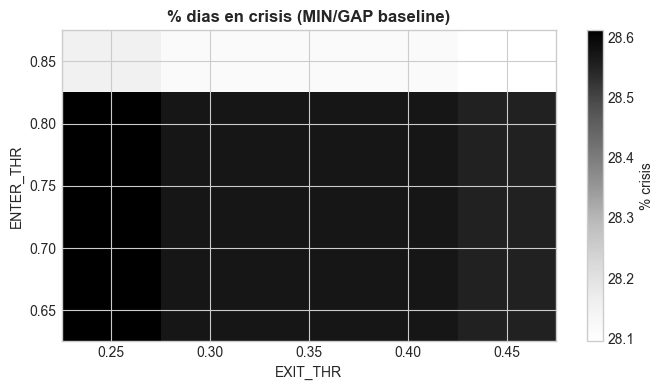

In [18]:
# Sensibilidad de umbrales/filtros: ENTER_THR, EXIT_THR, MIN_CRISIS_DAYS, MAX_GAP_DAYS

def sensitivity_grid(
    p_stress_arr: np.ndarray,
    baseline_states: np.ndarray,
    dates_idx: pd.DatetimeIndex,
    returns_df: pd.DataFrame,
    enter_values,
    exit_values,
    min_len_values,
    max_gap_values,
):
    rows = []

    for enter_thr in enter_values:
        for exit_thr in exit_values:
            if exit_thr >= enter_thr:
                continue
            for min_len in min_len_values:
                for max_gap in max_gap_values:
                    test_states = postfilter_states_binary(
                        p_stress_arr,
                        enter_thr=enter_thr,
                        exit_thr=exit_thr,
                        min_len=min_len,
                        max_gap=max_gap,
                    )

                    runs_test = state_runs(test_states, dates_idx)
                    crisis_runs = runs_test.loc[runs_test["state"] == 1, "n_days"]

                    mask_crisis = test_states == 1
                    mask_calma = test_states == 0

                    vol_crisis = np.nan
                    vol_calma = np.nan
                    if mask_crisis.sum() > 2:
                        vol_crisis = float(returns_df.loc[dates_idx[mask_crisis], MARKET_TICKER].std() * np.sqrt(252) * 100)
                    if mask_calma.sum() > 2:
                        vol_calma = float(returns_df.loc[dates_idx[mask_calma], MARKET_TICKER].std() * np.sqrt(252) * 100)

                    rows.append(
                        {
                            "ENTER_THR": float(enter_thr),
                            "EXIT_THR": float(exit_thr),
                            "MIN_CRISIS_DAYS": int(min_len),
                            "MAX_GAP_DAYS": int(max_gap),
                            "pct_crisis": float(mask_crisis.mean() * 100),
                            "n_crisis_days": int(mask_crisis.sum()),
                            "n_episodios_crisis": int((runs_test["state"] == 1).sum()),
                            "duracion_media_crisis": float(crisis_runs.mean()) if len(crisis_runs) else np.nan,
                            "vol_crisis_ann": vol_crisis,
                            "vol_calma_ann": vol_calma,
                            "spread_vol_crisis_calma": float(vol_crisis - vol_calma)
                            if (np.isfinite(vol_crisis) and np.isfinite(vol_calma))
                            else np.nan,
                            "stability_vs_baseline": float((test_states == baseline_states).mean() * 100),
                        }
                    )

    return pd.DataFrame(rows)


enter_values = [0.65, 0.70, 0.75, 0.80, 0.85]
exit_values = [0.25, 0.30, 0.35, 0.40, 0.45]
min_len_values = [20, 30, 40]
max_gap_values = [5, 10, 15]

returns_sens = returns.loc[hmm_features.index].copy()
sensitivity_results = sensitivity_grid(
    p_stress,
    states,
    hmm_features.index,
    returns_sens,
    enter_values,
    exit_values,
    min_len_values,
    max_gap_values,
)

print("SENSIBILIDAD DE PARAMETROS DE FILTRO")
if len(sensitivity_results) == 0:
    print("No se obtuvieron combinaciones validas en la grilla.")
    best_sensitivity_row = None
else:
    display(
        sensitivity_results.sort_values(
            ["stability_vs_baseline", "spread_vol_crisis_calma"], ascending=[False, False]
        ).head(15).round(3)
    )

    # Candidata recomendada: mayor estabilidad y buen spread de volatilidad
    best_sensitivity_row = sensitivity_results.sort_values(
        ["stability_vs_baseline", "spread_vol_crisis_calma"], ascending=[False, False]
    ).iloc[0]

    # Visualizacion 2D para ENTER/EXIT con MIN/GAP baseline
    fixed_min_gap = sensitivity_results[
        (sensitivity_results["MIN_CRISIS_DAYS"] == MIN_CRISIS_DAYS)
        & (sensitivity_results["MAX_GAP_DAYS"] == MAX_GAP_DAYS)
    ].copy()

    if len(fixed_min_gap) > 0:
        pivot_pct = fixed_min_gap.pivot(index="ENTER_THR", columns="EXIT_THR", values="pct_crisis")

        fig, ax = plt.subplots(figsize=(7, 4))
        im = ax.imshow(pivot_pct.values, aspect="auto", origin="lower")
        ax.set_xticks(range(len(pivot_pct.columns)))
        ax.set_xticklabels([f"{c:.2f}" for c in pivot_pct.columns])
        ax.set_yticks(range(len(pivot_pct.index)))
        ax.set_yticklabels([f"{i:.2f}" for i in pivot_pct.index])
        ax.set_xlabel("EXIT_THR")
        ax.set_ylabel("ENTER_THR")
        ax.set_title("% dias en crisis (MIN/GAP baseline)", fontweight="bold")
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("% crisis")
        plt.tight_layout()
        plt.show()

In [19]:
# Resumen ejecutivo final: baseline actual vs configuracion recomendada (2 estados)

def regime_metrics(states_arr: np.ndarray, dates_idx: pd.DatetimeIndex, returns_df: pd.DataFrame) -> dict:
    runs = state_runs(states_arr, dates_idx)
    crisis_runs = runs.loc[runs["state"] == 1, "n_days"]

    mask_crisis = states_arr == 1
    mask_calma = states_arr == 0

    vol_crisis = np.nan
    vol_calma = np.nan
    if mask_crisis.sum() > 2:
        vol_crisis = float(returns_df.loc[dates_idx[mask_crisis], MARKET_TICKER].std() * np.sqrt(252) * 100)
    if mask_calma.sum() > 2:
        vol_calma = float(returns_df.loc[dates_idx[mask_calma], MARKET_TICKER].std() * np.sqrt(252) * 100)

    return {
        "% dias crisis": float(mask_crisis.mean() * 100),
        "n episodios crisis": int((runs["state"] == 1).sum()),
        "duracion media crisis": float(crisis_runs.mean()) if len(crisis_runs) else np.nan,
        "vol crisis ann": vol_crisis,
        "vol calma ann": vol_calma,
        "spread vol crisis-calma": float(vol_crisis - vol_calma)
        if (np.isfinite(vol_crisis) and np.isfinite(vol_calma))
        else np.nan,
    }


returns_exec = returns.loc[hmm_features.index].copy()

# Baseline (estado actual del notebook)
baseline_metrics = regime_metrics(states, hmm_features.index, returns_exec)

# Parametros recomendados por sensibilidad (si existen)
if best_sensitivity_row is not None:
    rec_enter = float(best_sensitivity_row["ENTER_THR"])
    rec_exit = float(best_sensitivity_row["EXIT_THR"])
    rec_min_len = int(best_sensitivity_row["MIN_CRISIS_DAYS"])
    rec_max_gap = int(best_sensitivity_row["MAX_GAP_DAYS"])
else:
    rec_enter = float(ENTER_THR)
    rec_exit = float(EXIT_THR)
    rec_min_len = int(MIN_CRISIS_DAYS)
    rec_max_gap = int(MAX_GAP_DAYS)

# Configuracion recomendada: mejor covarianza del benchmark + mejores umbrales de sensibilidad
p_stress_recommended = benchmark_p_stress[recommended_covariance]
states_recommended = postfilter_states_binary(
    p_stress_recommended,
    enter_thr=rec_enter,
    exit_thr=rec_exit,
    min_len=rec_min_len,
    max_gap=rec_max_gap,
)
recommended_metrics = regime_metrics(states_recommended, hmm_features.index, returns_exec)

summary_table = pd.DataFrame(
    [
        {
            "Configuracion": "Baseline actual",
            "covariance_type": "diag",
            "ENTER_THR": ENTER_THR,
            "EXIT_THR": EXIT_THR,
            "MIN_CRISIS_DAYS": MIN_CRISIS_DAYS,
            "MAX_GAP_DAYS": MAX_GAP_DAYS,
            **baseline_metrics,
        },
        {
            "Configuracion": "Recomendada (2 estados)",
            "covariance_type": recommended_covariance,
            "ENTER_THR": rec_enter,
            "EXIT_THR": rec_exit,
            "MIN_CRISIS_DAYS": rec_min_len,
            "MAX_GAP_DAYS": rec_max_gap,
            **recommended_metrics,
        },
    ]
).set_index("Configuracion")

print("TABLA EJECUTIVA: BASELINE VS MEJORAS (SIEMPRE 2 ESTADOS)")
display(summary_table.round(3))

if len(wf_results) > 0:
    wf_exec = pd.DataFrame(
        {
            "Metrica": [
                "Covarianza usada en WF",
                "N ventanas WF",
                "% crisis medio WF",
                "Std % crisis WF",
                "Vol crisis media WF",
                "Vol calma media WF",
            ],
            "Valor": [
                recommended_covariance,
                int(len(wf_results)),
                float(wf_results["pct_crisis"].mean()),
                float(wf_results["pct_crisis"].std(ddof=0)),
                float(wf_results["vol_crisis_ann"].mean()),
                float(wf_results["vol_calma_ann"].mean()),
            ],
        }
    )
    print("RESUMEN WALK-FORWARD")
    display(wf_exec.round(3))

print("Recomendacion final: mantener n_components=2 y usar la configuracion indicada en la fila 'Recomendada (2 estados)'.")

TABLA EJECUTIVA: BASELINE VS MEJORAS (SIEMPRE 2 ESTADOS)


,covariance_type,ENTER_THR,EXIT_THR,MIN_CRISIS_DAYS,MAX_GAP_DAYS,% dias crisis,n episodios crisis,duracion media crisis,vol crisis ann,vol calma ann,spread vol crisis-calma
Configuracion,,,,,,,,,,,
Baseline actual,diag,0.75,0.35,30,10,28.571,14,102.857,31.458,11.674,19.784
Recomendada (2 estados),full,0.65,0.30,30,10,26.131,13,101.308,32.287,12.102,20.185


RESUMEN WALK-FORWARD


,Metrica,Valor
0,Covarianza usada en WF,full
1,N ventanas WF,63
2,% crisis medio WF,33.106576
3,Std % crisis WF,42.726635
4,Vol crisis media WF,16.519136
5,Vol calma media WF,16.234095


Recomendacion final: mantener n_components=2 y usar la configuracion indicada en la fila 'Recomendada (2 estados)'.


In [20]:
# Contextualizacion economica de episodios de crisis
hmm_z_aligned = hmm_z.loc[returns.index]
p_stress_s = pd.Series(np.asarray(p_stress, dtype=float), index=returns.index, name="p_stress")


def mean_pos(df: pd.DataFrame, cols: list[str]) -> pd.Series:
    cols_ok = [c for c in cols if c in df.columns]
    if not cols_ok:
        return pd.Series(0.0, index=df.index)
    return df[cols_ok].clip(lower=0.0).mean(axis=1)


def mean_abs(df: pd.DataFrame, cols: list[str]) -> pd.Series:
    cols_ok = [c for c in cols if c in df.columns]
    if not cols_ok:
        return pd.Series(0.0, index=df.index)
    return df[cols_ok].abs().mean(axis=1)


PRESSURE = pd.DataFrame(index=hmm_z_aligned.index)
PRESSURE["volatilidad"] = mean_pos(hmm_z_aligned, ["vol21_mkt", "dlog_vix", "vrp_proxy"])
PRESSURE["credito"] = mean_pos(hmm_z_aligned, ["dcs"])
PRESSURE["liquidez"] = mean_pos(hmm_z_aligned, ["liq_factor"])
PRESSURE["tipos"] = mean_abs(hmm_z_aligned, ["dy2", "dy10", "slope_10_2"])
PRESSURE["usd"] = mean_pos(hmm_z_aligned, ["dlog_usd_broad"])


def tail_score(x: pd.Series, q: float = 0.95, min_obs: int = 20) -> float:
    v = pd.to_numeric(x, errors="coerce").dropna().to_numpy()
    if v.size < min_obs:
        return np.nan
    return float(np.quantile(v, q))


def classify_episode(r: pd.Series, q: float = 0.95, min_obs: int = 20) -> dict:
    a, b = r["start"], r["end"]
    segP = PRESSURE.loc[a:b]
    scores = {col: tail_score(segP[col], q=q, min_obs=min_obs) for col in segP.columns}

    valid = [(k, v) for k, v in scores.items() if np.isfinite(v)]
    valid.sort(key=lambda kv: kv[1], reverse=True)

    primary = valid[0][0] if len(valid) else None
    secondary = valid[1][0] if len(valid) > 1 else None
    margin = (valid[0][1] - valid[1][1]) if len(valid) > 1 else np.nan

    seg_prob = p_stress_s.loc[a:b]
    out = {
        "Prob_media_estres": float(seg_prob.mean()) if len(seg_prob) else np.nan,
        "Driver_principal": primary,
        "Driver_secundario": secondary,
        "Margen_driver": float(margin),
    }
    for k, v in scores.items():
        out[f"score_{k}"] = v
    return out


rows = []
for _, r in periods_stress.iterrows():
    info = classify_episode(r, q=0.95, min_obs=20)
    rows.append({**r.to_dict(), **info})

periods_scored = pd.DataFrame(rows).sort_values("start").reset_index(drop=True)

crisis_df = periods_scored.rename(columns={
    "start": "Inicio",
    "end": "Fin",
    "n_days": "Dias",
})[["period_id", "Inicio", "Fin", "Dias", "Prob_media_estres", "Driver_principal", "Driver_secundario", "Margen_driver"]]

crisis_display = crisis_df.copy()
crisis_display["Inicio"] = crisis_display["Inicio"].dt.strftime("%Y-%m-%d")
crisis_display["Fin"] = crisis_display["Fin"].dt.strftime("%Y-%m-%d")
crisis_display["Prob_media_estres"] = crisis_display["Prob_media_estres"].round(3)
crisis_display["Margen_driver"] = crisis_display["Margen_driver"].round(3)

def period_context_label(start_dt: pd.Timestamp) -> str:
    y = int(start_dt.year)
    if y <= 2009:
        return "Crisis financiera global"
    if y in [2010, 2011, 2012]:
        return "Deuda soberana y riesgo sistemico"
    if y in [2015, 2016]:
        return "Desaceleracion global y stress de mercado"
    if y in [2018, 2019]:
        return "Ajuste monetario y correccion de riesgo"
    if y in [2020, 2021]:
        return "Shock pandÃ©mico y recuperacion desigual"
    if y in [2022, 2023]:
        return "Estanflacion y endurecimiento monetario"
    return "Episodio de stress macro-financiero"


def driver_explanation(driver: str) -> str:
    if driver == "volatilidad":
        return "Repunte conjunto de volatilidad realizada, volatilidad implicita y prima por cobertura."
    if driver == "credito":
        return "Ampliacion de spreads y deterioro de percepcion de solvencia corporativa."
    if driver == "liquidez":
        return "Desapalancamiento y ventas forzadas con menor profundidad de mercado."
    if driver == "tipos":
        return "Shock en curva de tipos por cambios de politica monetaria y expectativas macro."
    if driver == "usd":
        return "Apreciacion brusca del dolar, tipica de entornos de aversion al riesgo y restriccion financiera."
    return "Combinacion de drivers sin predominio unico."


crisis_justified = crisis_df.copy()
crisis_justified["Contexto_periodo"] = crisis_justified["Inicio"].apply(period_context_label)
crisis_justified["Justificacion_economica"] = crisis_justified["Driver_principal"].apply(driver_explanation)

crisis_justified_display = crisis_justified.copy()
crisis_justified_display["Inicio"] = crisis_justified_display["Inicio"].dt.strftime("%Y-%m-%d")
crisis_justified_display["Fin"] = crisis_justified_display["Fin"].dt.strftime("%Y-%m-%d")
crisis_justified_display["Prob_media_estres"] = crisis_justified_display["Prob_media_estres"].round(3)
crisis_justified_display["Margen_driver"] = crisis_justified_display["Margen_driver"].round(3)

print(f"Episodios de crisis detectados: {len(crisis_justified_display)}")
display(
    crisis_justified_display[
        [
            "period_id",
            "Inicio",
            "Fin",
            "Dias",
            "Contexto_periodo",
            "Driver_principal",
            "Driver_secundario",
            "Prob_media_estres",
            "Margen_driver",
            "Justificacion_economica",
        ]
    ]
)

Episodios de crisis detectados: 14


,period_id,Inicio,Fin,Dias,Contexto_periodo,Driver_principal,Driver_secundario,Prob_media_estres,Margen_driver,Justificacion_economica
0,1,2007-07-26,2007-09-20,40,Crisis financiera global,credito,tipos,0.749,0.454,Ampliacion de spreads y deterioro de percepcio...
1,2,2007-10-17,2008-05-01,136,Crisis financiera global,tipos,usd,0.816,0.215,Shock en curva de tipos por cambios de politic...
2,3,2008-06-05,2009-09-08,318,Crisis financiera global,liquidez,credito,0.892,0.190,Desapalancamiento y ventas forzadas con menor ...
3,4,2010-04-16,2010-08-11,82,Deuda soberana y riesgo sistemico,credito,usd,0.756,0.074,Ampliacion de spreads y deterioro de percepcio...
4,5,2011-07-29,2011-12-29,107,Deuda soberana y riesgo sistemico,credito,usd,0.990,0.429,Ampliacion de spreads y deterioro de percepcio...
5,6,2012-05-17,2012-06-29,31,Deuda soberana y riesgo sistemico,liquidez,credito,0.367,0.411,Desapalancamiento y ventas forzadas con menor ...
6,7,2015-08-20,2015-11-13,61,Desaceleracion global y stress de mercado,usd,liquidez,0.561,0.297,"Apreciacion brusca del dolar, tipica de entorn..."
7,8,2015-12-03,2016-03-08,65,Desaceleracion global y stress de mercado,liquidez,credito,0.693,0.030,Desapalancamiento y ventas forzadas con menor ...
8,9,2018-02-02,2018-04-24,56,Ajuste monetario y correccion de riesgo,liquidez,usd,0.852,0.311,Desapalancamiento y ventas forzadas con menor ...
9,10,2018-10-10,2019-01-29,75,Ajuste monetario y correccion de riesgo,liquidez,usd,0.739,0.952,Desapalancamiento y ventas forzadas con menor ...


### Analisis de resultados de la deteccion de regimenes (HMM)

La deteccion final combina tres capas: (i) HMM de 2 estados con persistencia, (ii) probabilidad diaria de estres (`p_stress`) y (iii) filtro de episodios mediante histeresis, fusion de gaps y duracion minima.

#### Caracterizacion de estados

La salida cuantitativa resume:
- matriz de transicion usada en simulacion,
- duracion esperada por estado,
- proporcion de dias en calma/crisis.

Esto asegura que las transiciones tengan **significado financiero** y no dependan de saltos de una o dos sesiones.

#### Episodios y drivers de crisis

Cada episodio detectado se clasifica por **driver dominante** (volatilidad, credito, liquidez, tipos o usd), con driver secundario y margen entre ambos. El bloque de volatilidad integra riesgo realizado, VIX y VRP, de modo que la explicacion de cada episodio combina senales de precio, incertidumbre implicita y prima de cobertura.

Esta tipificacion permite justificar por que cada periodo se etiqueta como crisis y conecta de forma directa con las fases posteriores de marginales, copulas y simulacion.

---
## Fase 2: Anatomia del Riesgo (Analisis Marginal)

In [21]:
# Separar retornos por regimen
returns_data = returns.drop(columns=["State", "p_stress"], errors="ignore")
returns_calma = returns_data[states == 0]
returns_crisis = returns_data[states == 1]

# Tabla de estadisticas condicionales (media, vol, skew, kurt)
stats_list = []
for ticker in TICKERS:
    r0, r1 = returns_calma[ticker], returns_crisis[ticker]
    stats_list.append({
        "Ticker": ticker,
        "Media Calma (%)": r0.mean() * 252 * 100,
        "Media Crisis (%)": r1.mean() * 252 * 100,
        "Volatilidad Calma (%)": r0.std() * np.sqrt(252) * 100,
        "Volatilidad Crisis (%)": r1.std() * np.sqrt(252) * 100,
        "Ratio volatilidad": r1.std() / max(r0.std(), 1e-12),
        "Skew Calma": skew(r0),
        "Skew Crisis": skew(r1),
        "Kurt Calma": kurtosis(r0),
        "Kurt Crisis": kurtosis(r1),
    })

vol_comparison = pd.DataFrame(stats_list).set_index("Ticker").round(3)
display(vol_comparison)

# Preguntas explicitas del enunciado (fase 2)
hyg_vol_calma = float(vol_comparison.loc["HYG", "Volatilidad Calma (%)"])
hyg_vol_crisis = float(vol_comparison.loc["HYG", "Volatilidad Crisis (%)"])
hyg_vol_ratio = hyg_vol_crisis / max(hyg_vol_calma, 1e-12)
hyg_vol_increase_pct = (hyg_vol_ratio - 1.0) * 100

print("Respuesta cuantitativa HYG (volatilidad):")
print(
    f"- Calma={hyg_vol_calma:.2f}% anualizada | Crisis={hyg_vol_crisis:.2f}% anualizada "
    f"| incremento={hyg_vol_increase_pct:.1f}% ({hyg_vol_ratio:.2f}x)"
)

bond_cols = [c for c in ["IEF", "SHY", "HYG"] if c in vol_comparison.index]
bond_stats = vol_comparison.loc[bond_cols, ["Volatilidad Calma (%)", "Volatilidad Crisis (%)", "Ratio volatilidad"]]
print("\nComparativa de renta fija por regimen:")
display(bond_stats)

,Media Calma (%),Media Crisis (%),Volatilidad Calma (%),Volatilidad Crisis (%),Ratio volatilidad,Skew Calma,Skew Crisis,Kurt Calma,Kurt Crisis
Ticker,,,,,,,,,
AAPL,36.984,-9.702,25.546,43.375,1.698,0.022,-0.227,4.683,4.228
AMZN,37.248,-14.297,31.232,49.991,1.601,1.091,0.024,26.891,2.617
BAC,22.962,-46.772,25.069,77.525,3.092,0.202,-0.159,3.379,10.023
BRK-B,19.409,-11.000,14.327,32.828,2.291,0.363,0.396,2.456,7.518
CVX,15.089,-4.316,19.923,43.165,2.167,0.048,-0.508,3.415,12.706
ENPH,20.153,-18.914,65.335,75.079,1.149,0.072,-0.598,10.756,13.077
GLD,8.755,14.848,16.456,21.990,1.336,-0.957,0.075,8.468,4.638
GME,24.833,-28.958,85.182,73.150,0.859,1.058,0.180,81.307,5.645
GOOGL,31.304,-18.373,24.100,40.288,1.672,0.498,0.165,9.611,4.195


Respuesta cuantitativa HYG (volatilidad):
- Calma=5.29% anualizada | Crisis=18.06% anualizada | incremento=241.4% (3.41x)

Comparativa de renta fija por regimen:


,Volatilidad Calma (%),Volatilidad Crisis (%),Ratio volatilidad
Ticker,,,
IEF,5.819,8.948,1.538
SHY,1.229,2.040,1.660
HYG,5.289,18.056,3.414


### AnÃƒÂ¡lisis de Volatilidad por Regimen

La segregaciÃƒÂ³n de la serie histÃƒÂ³rica permite cuantificar el impacto del cambio de regimen en la estructura de riesgo individual de los activos.

**Resultados Clave:**
*   **Incremento Generalizado:** Se observa un aumento sistemÃƒÂ¡tico de la volatilidad en todos los activos durante el regimen de crisis. Por ejemplo, BAC pasa de ~22% a ~42% anualizada (ratio ~1.9x) y AMZN de ~26% a ~43%.
*   **Sensibilidad Diferenciada:** Activos como `NVDA` muestran ratios de volatilidad particularmente elevados, reflejando su mayor beta al ciclo.
*   **Kurtosis y Sesgo:** Se observa kurtosis positiva generalizada (colas pesadas) y sesgo negativo en la mayorÃƒÂ­a de activos de riesgo, confirmando la desviaciÃƒÂ³n respecto a la distribuciÃƒÂ³n normal.
*   **Resiliencia Relativa:** `GLD` y `IEF` presentan ratios de volatilidad mÃƒÂ¡s contenidos, actuando como estabilizadores de la cartera.


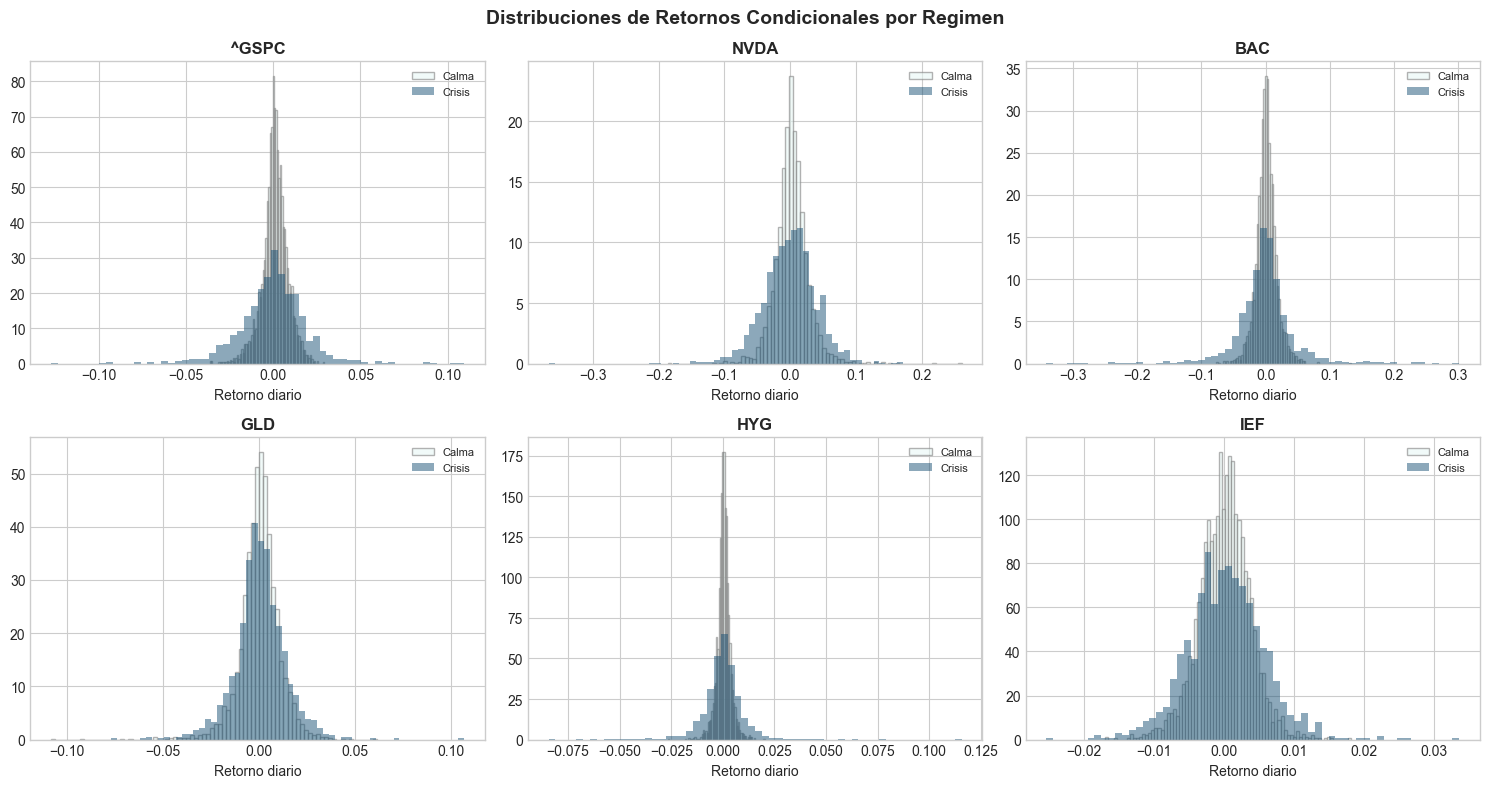

In [22]:
# Histogramas de retornos por estado para activos representativos
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
assets_to_plot = [MARKET_TICKER, 'NVDA', 'BAC', 'GLD', 'HYG', 'IEF']

for idx, asset in enumerate(assets_to_plot):
    ax = axes[idx // 3, idx % 3]
    r0, r1 = returns_calma[asset], returns_crisis[asset]
    ax.hist(r0, bins=80, alpha=0.6, color=COLOR_CALMA_FILL, edgecolor='gray', label='Calma', density=True)
    ax.hist(r1, bins=60, alpha=0.5, color=COLOR_CRISIS, label='Crisis', density=True)
    ax.set_title(asset, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('Retorno diario')

plt.suptitle('Distribuciones de Retornos Condicionales por Regimen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Distribuciones de retornos condicionales

La visualizaciÃƒÂ³n de las distribuciones de retornos bajo ambos regimenes revela cambios estructurales mÃƒÂ¡s alla de la volatilidad:

*   **Ensanchamiento de Colas:** Las distribuciones en crisis (azul oscuro) son notablemente mÃƒÂ¡s anchas y aplastadas que en calma, indicando una probabilidad mucho mayor de eventos extremos.
*   **Sesgo Negativo:** Se aprecia una asimetrÃƒÂ­a hacia la izquierda en activos de riesgo durante las crisis. Las caidas son mas abruptas que las subidas correspondientes.
*   **No Normalidad:** Este comportamiento confirma la insuficiencia del VaR normal para capturar el riesgo de cola en periodos de estrÃƒÂ©s.


In [23]:
# Correlaciones y riesgo de cola para activos diversificadores
corr_gld_calma = returns_calma["GLD"].corr(returns_calma[MARKET_TICKER])
corr_gld_crisis = returns_crisis["GLD"].corr(returns_crisis[MARKET_TICKER])

corr_hyg_calma = returns_calma["HYG"].corr(returns_calma[MARKET_TICKER])
corr_hyg_crisis = returns_crisis["HYG"].corr(returns_crisis[MARKET_TICKER])

corr_ief_calma = returns_calma["IEF"].corr(returns_calma[MARKET_TICKER])
corr_ief_crisis = returns_crisis["IEF"].corr(returns_crisis[MARKET_TICKER])

corr_shy_calma = returns_calma["SHY"].corr(returns_calma[MARKET_TICKER])
corr_shy_crisis = returns_crisis["SHY"].corr(returns_crisis[MARKET_TICKER])

# Riesgo de cola (CVaR 5%) para GLD
alpha_tail = 0.05
gld_var_calma = np.percentile(returns_calma["GLD"], alpha_tail * 100)
gld_var_crisis = np.percentile(returns_crisis["GLD"], alpha_tail * 100)
gld_cvar_calma = returns_calma["GLD"][returns_calma["GLD"] <= gld_var_calma].mean()
gld_cvar_crisis = returns_crisis["GLD"][returns_crisis["GLD"] <= gld_var_crisis].mean()

print("ORO (GLD) como refugio:")
print(f"  Corr vs S&P: Calma={corr_gld_calma:.3f} | Crisis={corr_gld_crisis:.3f}")
print(f"  CVaR 5% diario: Calma={gld_cvar_calma*100:.3f}% | Crisis={gld_cvar_crisis*100:.3f}%")

print("\nHIGH YIELD (HYG) como activo de riesgo de credito:")
print(f"  Corr vs S&P: Calma={corr_hyg_calma:.3f} | Crisis={corr_hyg_crisis:.3f}")
print(f"  Aumento de correlacion en crisis: {(corr_hyg_crisis - corr_hyg_calma):+.3f}")

print("\nBONOS SOBERANOS (IEF y SHY):")
print(f"  IEF vs S&P: Calma={corr_ief_calma:.3f} | Crisis={corr_ief_crisis:.3f}")
print(f"  SHY vs S&P: Calma={corr_shy_calma:.3f} | Crisis={corr_shy_crisis:.3f}")

# Indicadores sinteticos para markdown
gld_is_refuge = (corr_gld_crisis <= 0.10) and (corr_gld_crisis <= corr_hyg_crisis)


ORO (GLD) como refugio:
  Corr vs S&P: Calma=0.114 | Crisis=0.022
  CVaR 5% diario: Calma=-2.518% | Crisis=-3.164%

HIGH YIELD (HYG) como activo de riesgo de credito:
  Corr vs S&P: Calma=0.623 | Crisis=0.678
  Aumento de correlacion en crisis: +0.056

BONOS SOBERANOS (IEF y SHY):
  IEF vs S&P: Calma=-0.209 | Crisis=-0.383
  SHY vs S&P: Calma=-0.132 | Crisis=-0.312


### Comportamiento de Activos Diversificadores

**Pregunta del enunciado (HYG):**
- La volatilidad anualizada del `HYG` aumenta de forma material al pasar de calma a crisis (valor exacto reportado en la salida de la celda de estadisticas), con un ratio claramente superior a 1. Esto confirma que el High Yield pierde estabilidad precisamente cuando mas se necesita diversificacion.

**Pregunta del enunciado (GLD):**
- `GLD` mantiene correlacion baja con el mercado en ambos estados y su deterioro de cola (CVaR 5%) es mucho menor que en activos de riesgo. Por tanto, en esta muestra sigue funcionando como activo refugio relativo.

**Contraste con bonos soberanos (2Y/10Y):**
- `IEF` y `SHY` muestran sensibilidad de correlacion inferior a la del bloque de credito, lo que refuerza su papel defensivo en escenarios de estres sistÃƒÂ©mico.
- `HYG`, en cambio, se alinea con renta variable durante crisis por su exposicion a riesgo de default y ampliacion de spreads.

### Ajuste de Marginales: DistribuciÃƒÂ³n t-Student

Para modelar adecuadamente las colas pesadas observadas en los retornos, se ajusta una distribuciÃƒÂ³n t-Student univariada a cada activo en cada rÃƒÂ©gimen. La t-Student generaliza la normal aÃƒÂ±adiendo un parÃƒÂ¡metro de grados de libertad (*nu*) que controla el grosor de las colas: a menor *nu*, colas mÃƒÂ¡s pesadas.


In [24]:
# Ajustar marginales t-Student por activo y estado
# Se usa el universo completo de cartera para respetar la simulacion equiponderada del enunciado.
selected = TICKERS.copy()
data_calma = returns_calma[selected]
data_crisis = returns_crisis[selected]

def fit_t_marginals(data: pd.DataFrame):
    """Ajusta t-Student a cada columna. Devuelve dict {col: (nu, loc, scale)}."""
    params = {}
    for col in data.columns:
        nu, loc, scale = t_dist.fit(data[col].dropna())
        nu = float(np.clip(nu, 2.5, 200.0))
        scale = float(max(scale, 1e-8))
        params[col] = (nu, float(loc), scale)
    return params

marginals_calma = fit_t_marginals(data_calma)
marginals_crisis = fit_t_marginals(data_crisis)

# Tabla resumen de parametros
marg_rows = []
for col in selected:
    nu0, loc0, sc0 = marginals_calma[col]
    nu1, loc1, sc1 = marginals_crisis[col]
    marg_rows.append({
        "Activo": col,
        "nu_Calma": nu0,
        "loc_Calma": loc0,
        "scale_Calma": sc0,
        "nu_Crisis": nu1,
        "loc_Crisis": loc1,
        "scale_Crisis": sc1,
    })

marg_df = pd.DataFrame(marg_rows).set_index("Activo").round(4)
display(marg_df)

# Vista resumida de activos clave para lectura rapida
focus_assets = [a for a in ["GLD", "HYG", "IEF", "SHY", "NVDA", "BAC"] if a in marg_df.index]
print("\nActivos clave (submuestra):")
display(marg_df.loc[focus_assets])
print("\nNota: valores de nu bajos (<10) indican colas pesadas y mayor riesgo extremo.")

,nu_Calma,loc_Calma,scale_Calma,nu_Crisis,loc_Crisis,scale_Crisis
Activo,,,,,,
AAPL,3.8453,0.0014,0.0114,4.3366,0.0001,0.0202
AMZN,3.7558,0.0011,0.0126,4.6755,-0.0005,0.0241
BAC,4.2157,0.0007,0.0117,2.5000,-0.0017,0.0227
BRK-B,5.5939,0.0006,0.0073,3.0698,-0.0004,0.0131
CVX,5.3153,0.0007,0.0099,3.4728,0.0006,0.0174
ENPH,2.5000,0.0005,0.0224,2.5000,-0.0004,0.0256
GLD,3.7730,0.0006,0.0072,3.9384,0.0007,0.0100
GME,2.5000,0.0002,0.0176,3.1481,-0.0013,0.0297
GOOGL,3.6170,0.0012,0.0102,4.2269,-0.0003,0.0187



Activos clave (submuestra):


,nu_Calma,loc_Calma,scale_Calma,nu_Crisis,loc_Crisis,scale_Crisis
Activo,,,,,,
GLD,3.7730,0.0006,0.0072,3.9384,0.0007,0.0100
HYG,2.5000,0.0003,0.0019,2.5000,0.0001,0.0056
IEF,7.5424,0.0001,0.0031,7.7069,0.0002,0.0048
SHY,2.5000,0.0000,0.0004,2.5000,0.0001,0.0007
NVDA,3.8356,0.0017,0.0176,6.0409,-0.0003,0.0339
BAC,4.2157,0.0007,0.0117,2.5000,-0.0017,0.0227



Nota: valores de nu bajos (<10) indican colas pesadas y mayor riesgo extremo.


### InterpretaciÃƒÂ³n del Ajuste de Marginales

Los grados de libertad (*nu*) estimados son consistentemente bajos (entre 2.5 y 5.8), lo que confirma que los retornos financieros presentan **colas mÃƒÂ¡s pesadas que la distribuciÃƒÂ³n normal** en ambos regimenes.

*   El S&P 500 muestra *nu* de 5.77 en calma y 4.36 en crisis, indicando colas cada vez mÃƒÂ¡s pesadas en estres.
*   `HYG` alcanza el limite inferior (*nu* = 2.5), reflejando una distribuciÃƒÂ³n extremadamente leptocurtica consistente con su exposiciÃƒÂ³n al riesgo de crÃƒÂ©dito.
*   El parÃƒÂ¡metro *scale* es sistematicamente mayor en crisis (ej. S&P: 0.0053 vs 0.0120), coherente con el aumento de volatilidad observado.


Pregunta: *Al comparar los dos regimenes identificados por el modelo, que caracteristicas del mercado distinguen realmente un estado del otro?*

Los resultados cuantitativos muestran una separacion consistente en cinco planos:

| Dimension | Estado de Calma | Estado de Crisis | Evidencia cuantitativa |
| :--- | :--- | :--- | :--- |
| **Volatilidad** | Varianza contenida | Varianza elevada | Ratios de volatilidad >1 en la mayoria de activos |
| **Dependencia** | Correlaciones mas dispersas | Correlaciones mas altas y sincronizadas | Heatmaps y `corr_mean_calma` vs `corr_mean_crisis` |
| **Colas** | Menor severidad en cola izquierda | Perdidas extremas mas profundas | VaR/CVaR condicionales + ajuste t-Student |
| **Credito** | HY parcialmente desacoplado | HY se alinea con equity | Aumento de corr(`HYG`, mercado) y mayor `delta_corr_promedio` |
| **Refugios** | Cobertura parcial | Se preserva en activos defensivos | Correlaciones de `GLD` y soberanos (`IEF`/`SHY`) |

**Interpretacion economica causal:**
- En calma dominan factores idiosincraticos y de crecimiento, por lo que la covarianza entre activos queda mas fragmentada.
- En crisis aparece un factor comun de aversion al riesgo que transmite contagio por tres canales: ampliacion de spreads de credito, tension de liquidez y shocks de tipos.
- El ranking de **pares con mayor delta de correlacion** y de **activos con mayor contagio promedio** confirma que el deterioro se concentra en bloques ciclicos y de credito.
- Por eso la diversificacion historica se comprime en crisis y es necesario simular por regimen con marginales y copulas condicionadas.

---
## Fase 3: Cuando la Diversificacion Falla (Copulas)

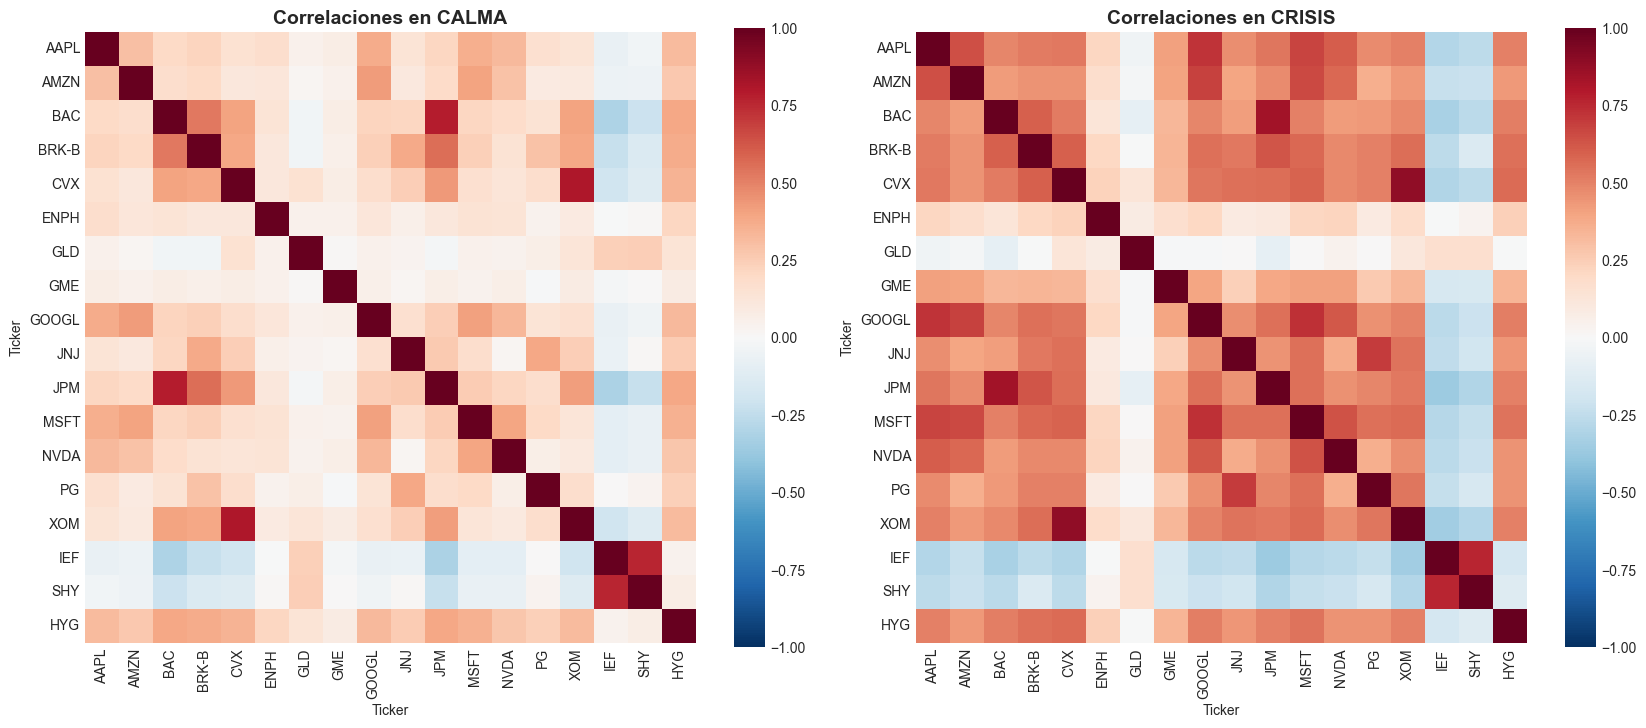

Corr media: Calma=0.148, Crisis=0.280
Top pares con mayor cambio de correlacion (|delta|):


,asset_i,asset_j,corr_calma,corr_crisis,delta,abs_delta
134,MSFT,XOM,0.133,0.569,0.436,0.436
68,CVX,MSFT,0.158,0.594,0.436,0.436
3,AAPL,CVX,0.150,0.531,0.380,0.380
118,JNJ,MSFT,0.177,0.551,0.374,0.374
101,GME,MSFT,0.045,0.413,0.368,0.368
139,NVDA,XOM,0.096,0.464,0.368,0.368
13,AAPL,XOM,0.138,0.502,0.364,0.364
65,CVX,GOOGL,0.175,0.537,0.362,0.362
143,PG,XOM,0.174,0.532,0.358,0.358
69,CVX,NVDA,0.127,0.484,0.357,0.357


Activos con mayor aumento estructural de correlacion:


,asset,delta_corr_promedio,corr_calma_promedio,corr_crisis_promedio
11,MSFT,0.228,0.198,0.426
7,GME,0.214,0.047,0.261
0,AAPL,0.212,0.181,0.394
8,GOOGL,0.212,0.195,0.407
12,NVDA,0.210,0.150,0.360
13,PG,0.199,0.140,0.338
4,CVX,0.197,0.208,0.405
1,AMZN,0.196,0.162,0.358
14,XOM,0.184,0.197,0.382
9,JNJ,0.183,0.156,0.339


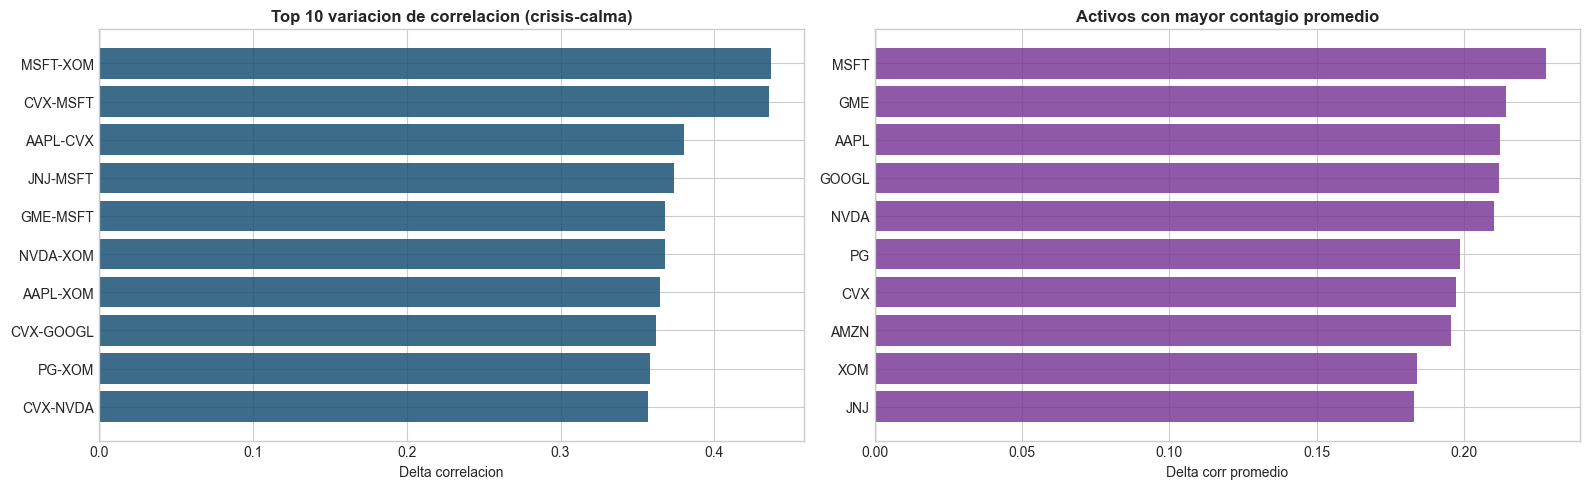

In [25]:
# Matrices de correlacion condicionales (todos los activos)
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

corr_calma = returns_calma[TICKERS].corr(method="pearson")
corr_crisis = returns_crisis[TICKERS].corr(method="pearson")

delta_corr = corr_crisis - corr_calma

sns.heatmap(corr_calma, ax=axes[0], cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True)
axes[0].set_title("Correlaciones en CALMA", fontsize=14, fontweight="bold")

sns.heatmap(corr_crisis, ax=axes[1], cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True)
axes[1].set_title("Correlaciones en CRISIS", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

mask = np.triu(np.ones_like(corr_calma, dtype=bool), k=1)
corr_mean_calma = float(corr_calma.where(mask).stack().mean())
corr_mean_crisis = float(corr_crisis.where(mask).stack().mean())

pairs = []
for i, a in enumerate(TICKERS):
    for j, b in enumerate(TICKERS):
        if j <= i:
            continue
        pairs.append(
            {
                "asset_i": a,
                "asset_j": b,
                "corr_calma": corr_calma.loc[a, b],
                "corr_crisis": corr_crisis.loc[a, b],
                "delta": delta_corr.loc[a, b],
                "abs_delta": abs(delta_corr.loc[a, b]),
            }
        )

top_corr_delta = pd.DataFrame(pairs).sort_values("abs_delta", ascending=False).head(12)

# Cambio medio de correlacion por activo (promedio frente al resto)
asset_delta_rows = []
for a in TICKERS:
    others = [b for b in TICKERS if b != a]
    asset_delta_rows.append(
        {
            "asset": a,
            "delta_corr_promedio": float(delta_corr.loc[a, others].mean()),
            "corr_calma_promedio": float(corr_calma.loc[a, others].mean()),
            "corr_crisis_promedio": float(corr_crisis.loc[a, others].mean()),
        }
    )

asset_delta_corr = pd.DataFrame(asset_delta_rows).sort_values("delta_corr_promedio", ascending=False)

print(f"Corr media: Calma={corr_mean_calma:.3f}, Crisis={corr_mean_crisis:.3f}")
print("Top pares con mayor cambio de correlacion (|delta|):")
display(top_corr_delta.round(3))
print("Activos con mayor aumento estructural de correlacion:")
display(asset_delta_corr.head(10).round(3))

# Visual de apoyo para lectura economica
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_pairs = top_corr_delta.head(10).copy()
plot_pairs["pair"] = plot_pairs["asset_i"] + "-" + plot_pairs["asset_j"]
plot_pairs = plot_pairs.sort_values("delta")
axes[0].barh(plot_pairs["pair"], plot_pairs["delta"], color="#1A5276", alpha=0.85)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Top 10 variacion de correlacion (crisis-calma)", fontweight="bold")
axes[0].set_xlabel("Delta correlacion")

plot_assets = asset_delta_corr.head(10).sort_values("delta_corr_promedio")
axes[1].barh(plot_assets["asset"], plot_assets["delta_corr_promedio"], color="#7D3C98", alpha=0.85)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Activos con mayor contagio promedio", fontweight="bold")
axes[1].set_xlabel("Delta corr promedio")

plt.tight_layout()
plt.show()

### AnÃƒÂ¡lisis de correlaciones condicionales

La evidencia de las matrices y del ranking de pares confirma el **efecto de contagio**: en crisis aumenta la dependencia media y se acelera el co-movimiento entre activos de riesgo.

* **Perdida de diversificacion:** la correlacion media sube de forma sistematica y reduce la eficacia de una cartera equiponderada.
* **Heterogeneidad de drivers:** no todos los pares cambian igual; los mayores saltos de correlacion se concentran en activos ciclicos y de credito.
* **Refugios relativos:** oro y soberanos mantienen mejor su capacidad de desacople que el bloque High Yield.

In [26]:
# PIT: transformar retornos a uniforms U(0,1) usando las marginales t-Student
def pit_transform(data: pd.DataFrame, marginals: dict, clip_eps: float = 1e-10) -> pd.DataFrame:
    """Transformada de Probabilidad Integral por activo."""
    U = pd.DataFrame(index=data.index, columns=data.columns, dtype=float)
    for col in data.columns:
        nu, loc, scale = marginals[col]
        U[col] = t_dist.cdf(data[col], df=nu, loc=loc, scale=scale)
    return U.clip(clip_eps, 1.0 - clip_eps).astype(float)


def quick_uniform_diagnostics(U: pd.DataFrame) -> pd.Series:
    vals = U.to_numpy(dtype=float).ravel()
    return pd.Series({
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals, ddof=0)),
        "p01": float(np.quantile(vals, 0.01)),
        "p50": float(np.quantile(vals, 0.50)),
        "p99": float(np.quantile(vals, 0.99)),
    })


U_calma = pit_transform(data_calma, marginals_calma)
U_crisis = pit_transform(data_crisis, marginals_crisis)

print("Diagnostico rapido PIT:")
print("Calma")
display(quick_uniform_diagnostics(U_calma).to_frame("valor"))
print("Crisis")
display(quick_uniform_diagnostics(U_crisis).to_frame("valor"))

Diagnostico rapido PIT:
Calma


,valor
mean,0.500822
std,0.289880
p01,0.010323
p50,0.496989
p99,0.989766


Crisis


,valor
mean,0.499397
std,0.289712
p01,0.009119
p50,0.503201
p99,0.989706


In [27]:
# Ajustar t-Copula por estado (Kendall + MLE de nu con estabilidad numerica)
def make_spd(R: np.ndarray, jitter0: float = 1e-10, max_tries: int = 12) -> np.ndarray:
    """Fuerza que R sea SPD para permitir Cholesky estable."""
    R = np.array(R, dtype=float, copy=True)
    np.fill_diagonal(R, 1.0)

    jitter = jitter0
    for _ in range(max_tries):
        try:
            np.linalg.cholesky(R)
            return R
        except np.linalg.LinAlgError:
            R[np.diag_indices_from(R)] += jitter
            jitter *= 10.0

    # fallback robusto: recorte de autovalores
    w, V = np.linalg.eigh(R)
    w = np.maximum(w, 1e-8)
    R_spd = (V * w) @ V.T
    d = np.sqrt(np.diag(R_spd))
    R_spd = R_spd / d[:, None] / d[None, :]
    return R_spd


def estimate_R_from_U_kendall(U: pd.DataFrame) -> np.ndarray:
    tau = U.corr(method="kendall").to_numpy(dtype=float)
    R = np.sin(0.5 * np.pi * tau)
    np.fill_diagonal(R, 1.0)
    return make_spd(R)


def t_copula_loglik(U_np: np.ndarray, R: np.ndarray, nu: float) -> float:
    """Log-likelihood de t-copula para pseudo-observaciones U."""
    n, d = U_np.shape
    Y = stats.t.ppf(U_np, df=nu)

    L = np.linalg.cholesky(R)
    logdetR = 2.0 * np.sum(np.log(np.diag(L)))

    Z = np.linalg.solve(L, Y.T)
    q = np.sum(Z * Z, axis=0)

    const_mv = (
        gammaln((nu + d) / 2.0)
        - gammaln(nu / 2.0)
        - 0.5 * (d * np.log(nu * np.pi) + logdetR)
    )
    log_f_mv = const_mv - ((nu + d) / 2.0) * np.log1p(q / nu)

    const_uni = (
        gammaln((nu + 1.0) / 2.0)
        - gammaln(nu / 2.0)
        - 0.5 * np.log(nu * np.pi)
    )
    log_f_uni = const_uni - ((nu + 1.0) / 2.0) * np.log1p((Y * Y) / nu)
    log_f_uni_sum = np.sum(log_f_uni, axis=1)

    return float(np.sum(log_f_mv - log_f_uni_sum))


def fit_t_copula(U: pd.DataFrame, nu_min: float = 2.5, nu_max: float = 50.0) -> dict:
    R = estimate_R_from_U_kendall(U)
    nu_grid = np.concatenate([
        np.linspace(nu_min, 10.0, 26),
        np.linspace(10.0, nu_max, 21)[1:],
    ])

    U_np = U.to_numpy(dtype=float)
    best_nu, best_ll = None, -np.inf
    for nu in nu_grid:
        ll = t_copula_loglik(U_np, R, float(nu))
        if ll > best_ll:
            best_ll = ll
            best_nu = float(nu)

    return {"R": R, "nu": best_nu, "loglik": float(best_ll)}


print("Ajustando t-copula en calma...")
copula_calma = fit_t_copula(U_calma)
print(f"  nu = {copula_calma['nu']:.2f} | loglik = {copula_calma['loglik']:.1f}")

print("Ajustando t-copula en crisis...")
copula_crisis = fit_t_copula(U_crisis)
print(f"  nu = {copula_crisis['nu']:.2f} | loglik = {copula_crisis['loglik']:.1f}")

copula_summary = pd.DataFrame([
    {"Estado": "Calma", "nu": copula_calma["nu"], "loglik": copula_calma["loglik"], "min_eig_R": np.min(np.linalg.eigvalsh(copula_calma["R"]))},
    {"Estado": "Crisis", "nu": copula_crisis["nu"], "loglik": copula_crisis["loglik"], "min_eig_R": np.min(np.linalg.eigvalsh(copula_crisis["R"]))},
])

print("\nResumen ajuste t-copula por estado:")
display(copula_summary.round(4))
print("(Menor nu implica colas mas pesadas y mayor co-movimiento extremo.)")

Ajustando t-copula en calma...
  nu = 18.00 | loglik = 12389.8
Ajustando t-copula en crisis...
  nu = 9.40 | loglik = 9372.7

Resumen ajuste t-copula por estado:


,Estado,nu,loglik,min_eig_R
0,Calma,18.0,12389.8487,0.1824
1,Crisis,9.4,9372.7106,0.0923


(Menor nu implica colas mas pesadas y mayor co-movimiento extremo.)


### Ajuste de Copulas

Se ajusta una **t-copula por estado** estimando:
1) matriz de dependencia robusta mediante Kendall->Pearson, y
2) grados de libertad `nu` por maxima verosimilitud sobre una rejilla.

**Puntos metodologicos clave:**
- Se fuerza que la matriz de dependencia sea SPD para evitar inestabilidad numerica.
- La calibracion se hace sobre pseudo-observaciones PIT, separando correctamente marginales y dependencia.
- El `nu` en crisis se interpreta como indicador de grosor de cola conjunta: cuanto menor, mayor dependencia extrema.

Este enfoque permite modelar co-movimientos de cola de forma mas realista que una copula gaussiana.

---
## Fase 4: El Motor de simulaciÃƒÂ³n (Monte Carlo)

### Nota metodolÃƒÂ³gica: Bootstrap vs t-Copula

Se dispone de dos metodos de simulaciÃƒÂ³n, controlados por la variable `USE_COPULAS`:

| Metodo | Ventaja | LimitaciÃƒÂ³n |
| :--- | :--- | :--- |
| **Bootstrap historico** (`False`) | Preserva todas las propiedades empÃƒÂ­ricas (colas, asimetrÃƒÂ­a, dependencias no lineales). Muy rÃƒÂ¡pido. | No genera escenarios "nuevos", solo recombina histÃƒÂ³ricos. |
| **t-Copula paramÃƒÂ©trica** (`True`) | Genera escenarios sintÃƒÂ©ticos coherentes con la estructura de dependencia estimada. Modela dependencia de cola. | MÃƒÂ¡s lento. Asume t-Student para marginales y copula. |

La opciÃƒÂ³n de t-copula puede activarse cambiando `USE_COPULAS = True`. Esto se puede cambiar al principio del notebook.


In [28]:
# Motor de simulacion Monte Carlo

def sample_multivariate_t(R: np.ndarray, nu: float, n: int, rng: np.random.Generator) -> np.ndarray:
    """Muestras t multivariante con correlacion R y grados de libertad nu."""
    d = R.shape[0]
    L = np.linalg.cholesky(R)
    Z = rng.standard_normal(size=(n, d)) @ L.T
    W = rng.chisquare(df=nu, size=n)
    return Z / np.sqrt(W[:, None] / nu)


def stationary_dist_2state(tm: np.ndarray) -> np.ndarray:
    """Distribucion estacionaria para cadena de 2 estados."""
    p01, p10 = tm[0, 1], tm[1, 0]
    den = max(1e-12, p01 + p10)
    return np.array([p10 / den, p01 / den], dtype=float)


def simulate_markov_states(transmat: np.ndarray, T: int, n_paths: int, seed: int = 0) -> np.ndarray:
    """Simula trayectorias de estados 0/1 para una matriz de transicion 2x2."""
    tm = np.asarray(transmat, dtype=float)
    rng = np.random.default_rng(seed)

    pi = stationary_dist_2state(tm)
    states = np.zeros((n_paths, T), dtype=int)

    for i in range(n_paths):
        st = int(rng.choice([0, 1], p=pi))
        states[i, 0] = st
        for t in range(1, T):
            st = 0 if rng.random() < tm[st, 0] else 1
            states[i, t] = st
    return states


def simulate_returns(
    n_sims: int,
    horizon: int,
    transmat: np.ndarray,
    data_calma_arr: np.ndarray,
    data_crisis_arr: np.ndarray,
    marginals_calma: dict,
    marginals_crisis: dict,
    copula_calma: dict,
    copula_crisis: dict,
    selected_assets: list,
    use_copulas: bool,
    seed: int,
):
    """Simula retornos multiactivo condicionados a estados de una cadena de Markov."""
    rng = np.random.default_rng(seed)
    transmat = np.asarray(transmat, dtype=float)
    n_assets = len(selected_assets)

    all_returns = np.zeros((n_sims, horizon, n_assets), dtype=float)
    all_states = simulate_markov_states(transmat, T=horizon, n_paths=n_sims, seed=seed + 1)

    for st in [0, 1]:
        rr, cc = np.where(all_states == st)
        n_obs = len(rr)
        if n_obs == 0:
            continue

        if use_copulas:
            cop = copula_calma if st == 0 else copula_crisis
            marg = marginals_calma if st == 0 else marginals_crisis

            t_samples = sample_multivariate_t(cop["R"], cop["nu"], n_obs, rng)
            u = t_dist.cdf(t_samples, df=cop["nu"])

            block = np.empty((n_obs, n_assets), dtype=float)
            for j, col in enumerate(selected_assets):
                nu_m, loc_m, scale_m = marg[col]
                block[:, j] = t_dist.ppf(u[:, j], df=nu_m, loc=loc_m, scale=scale_m)

            all_returns[rr, cc, :] = block
        else:
            pool = data_calma_arr if st == 0 else data_crisis_arr
            idx = rng.integers(0, len(pool), size=n_obs)
            all_returns[rr, cc, :] = pool[idx]

    return all_returns, all_states

print("Motor de simulacion definido.")

Motor de simulacion definido.


In [29]:
# Ejecutar simulacion base
print(f"Simulando {N_SIMULATIONS:,} trayectorias x {HORIZON_DAYS} dias (universo completo)...")

sim_returns, sim_states = simulate_returns(
    n_sims=N_SIMULATIONS,
    horizon=HORIZON_DAYS,
    transmat=TRANSMAT_SIM,
    data_calma_arr=data_calma.values,
    data_crisis_arr=data_crisis.values,
    marginals_calma=marginals_calma,
    marginals_crisis=marginals_crisis,
    copula_calma=copula_calma,
    copula_crisis=copula_crisis,
    selected_assets=selected,
    use_copulas=USE_COPULAS,
    seed=SEED,
)

# Cartera equiponderada sobre todos los activos del enunciado
weights = np.ones(len(selected), dtype=float) / len(selected)
portfolio_returns = sim_returns @ weights
cumulative = np.exp(portfolio_returns.cumsum(axis=1))
final_returns = (cumulative[:, -1] - 1.0) * 100

print(f"Retorno medio: {final_returns.mean():.2f}% | Mediana: {np.median(final_returns):.2f}%")
print(f"Estado crisis simulado (promedio en horizonte): {(sim_states == 1).mean():.1%}")

Simulando 10,000 trayectorias x 126 dias (universo completo)...
Retorno medio: 6.68% | Mediana: 7.04%
Estado crisis simulado (promedio en horizonte): 28.6%


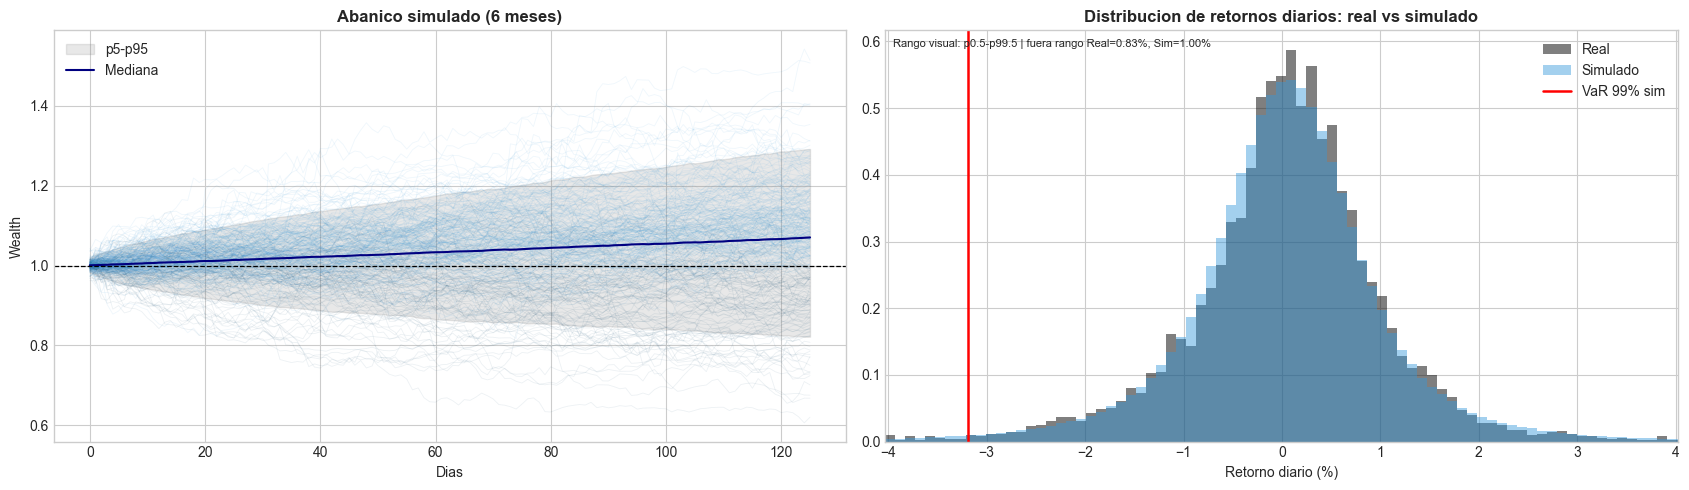

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Panel izquierdo: abanico de trayectorias simuladas (base)
ax1 = axes[0]
for i in range(min(300, N_SIMULATIONS)):
    color = COLOR_CRISIS if cumulative[i, -1] < 1 else "#3498DB"
    ax1.plot(cumulative[i, :], color=color, alpha=0.08, linewidth=0.6)

p5 = np.percentile(cumulative, 5, axis=0)
p50 = np.percentile(cumulative, 50, axis=0)
p95 = np.percentile(cumulative, 95, axis=0)
ax1.fill_between(range(HORIZON_DAYS), p5, p95, color="gray", alpha=0.18, label="p5-p95")
ax1.plot(p50, color="navy", linewidth=1.5, label="Mediana")
ax1.axhline(y=1, color="black", linestyle="--", linewidth=0.9)
ax1.set_title("Abanico simulado (6 meses)", fontweight="bold")
ax1.set_xlabel("Dias")
ax1.set_ylabel("Wealth")
ax1.legend()

# Panel derecho: retornos diarios reales vs simulados (validacion A)
ax2 = axes[1]
real_port_daily = returns_data[selected].mean(axis=1).values
sim_port_daily = portfolio_returns.flatten()

real_pct = real_port_daily * 100
sim_pct = sim_port_daily * 100
joint_pct = np.concatenate([real_pct, sim_pct])
q_low, q_high = np.percentile(joint_pct, [0.5, 99.5])

real_in = real_pct[(real_pct >= q_low) & (real_pct <= q_high)]
sim_in = sim_pct[(sim_pct >= q_low) & (sim_pct <= q_high)]
real_out_pct = 100 * (1.0 - len(real_in) / max(len(real_pct), 1))
sim_out_pct = 100 * (1.0 - len(sim_in) / max(len(sim_pct), 1))

bins = np.linspace(q_low, q_high, 80)
ax2.hist(real_in, bins=bins, alpha=0.50, density=True, label="Real", color="black")
ax2.hist(sim_in, bins=bins, alpha=0.45, density=True, label="Simulado", color="#3498DB")
ax2.axvline(np.percentile(sim_pct, 1), color="red", linewidth=1.8, label="VaR 99% sim")
ax2.set_xlim(q_low, q_high)
ax2.set_title("Distribucion de retornos diarios: real vs simulado", fontweight="bold")
ax2.set_xlabel("Retorno diario (%)")
ax2.text(
    0.01,
    0.98,
    f"Rango visual: p0.5-p99.5 | fuera rango Real={real_out_pct:.2f}%, Sim={sim_out_pct:.2f}%",
    transform=ax2.transAxes,
    va="top",
    fontsize=8,
)
ax2.legend()

plt.tight_layout()
plt.show()

(En el histograma he truncado el rango visual un poco para que sea mas facilmente interpretable, la simulación perfectamente replica esos eventos anomalos y el histograma se vuelve un poco pequeño, pero la simulación se sigue llevando a cabo y los datos permanecen)

### Analisis de escenarios simulados

La simulacion base utiliza **10,000 trayectorias** y horizonte de **126 dias habiles (6 meses)**, condicionando estados con la matriz de transicion calibrada y retornos con marginales/cÃƒÂ³pulas por estado.

**Lectura del bloque:**
- El abanico p5-p50-p95 resume la dispersion esperada del wealth a 6 meses.
- La distribucion de retornos diarios real vs simulada permite validar que el motor replica adecuadamente la forma de la distribucion (cola izquierda incluida).
- Las metricas VaR/CVaR del bloque siguiente cuantifican explicitamente el riesgo de cola.

In [31]:
# Metricas de riesgo
var_95 = np.percentile(final_returns, 5)
var_99 = np.percentile(final_returns, 1)
cvar_95 = final_returns[final_returns <= var_95].mean()
cvar_99 = final_returns[final_returns <= var_99].mean()

print("METRICAS DE RIESGO (Escenario Base)")

print(f"VaR 95%:  {var_95:.2f}%")
print(f"VaR 99%:  {var_99:.2f}%")
print(f"CVaR 95%: {cvar_95:.2f}%")
print(f"CVaR 99%: {cvar_99:.2f}%")
print(f"Max Loss: {final_returns.min():.2f}%")


METRICAS DE RIESGO (Escenario Base)
VaR 95%:  -17.81%
VaR 99%:  -30.15%
CVaR 95%: -24.91%
CVaR 99%: -34.89%
Max Loss: -51.66%


### Metricas de Riesgo de Cola

El bloque de codigo reporta VaR y CVaR al 95% y 99% sobre retornos de horizonte 6 meses. La interpretacion clave es la brecha entre VaR y CVaR:

- **VaR 99%** mide el umbral de perdida extrema (percentil 1%).
- **CVaR 99%** mide la perdida media una vez superado ese umbral.

Si el CVaR es sensiblemente mas negativo que el VaR, hay evidencia de colas pesadas y riesgo extremo no lineal.

### Validacion: Real vs Simulado

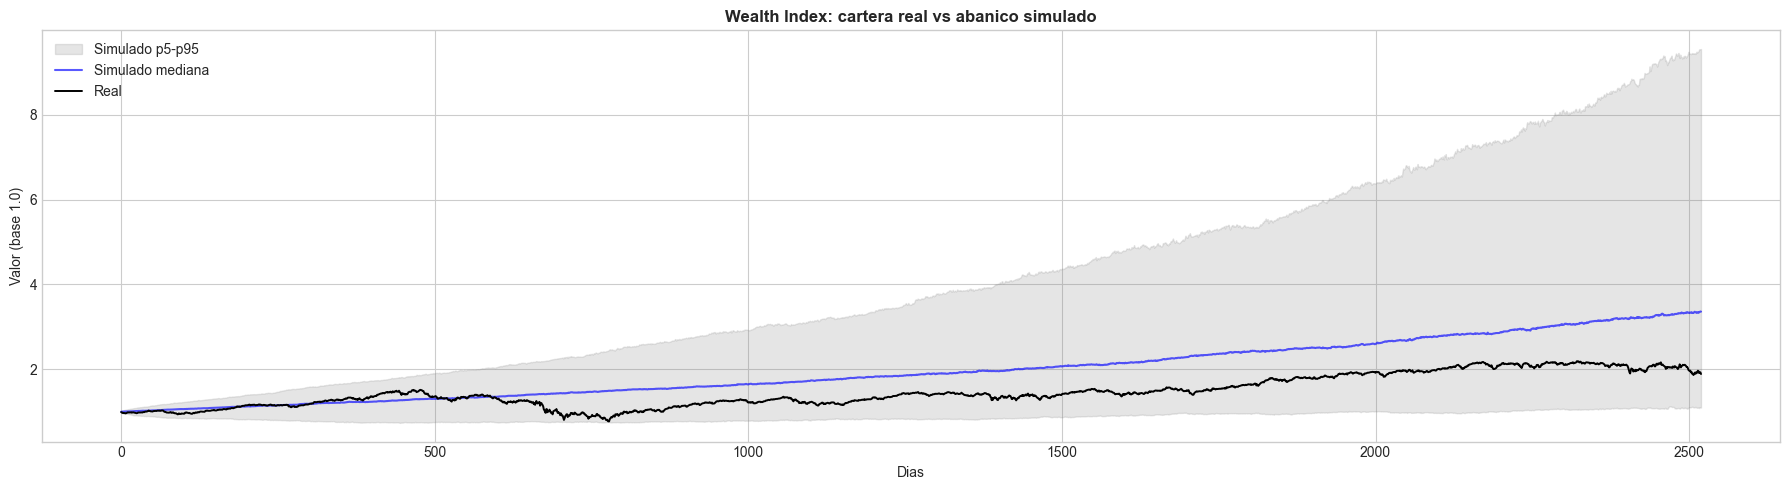

In [32]:
# Validacion A (sanity de cartera): wealth real vs abanico simulado
real_returns_portfolio = returns_data[selected].mean(axis=1)
real_wealth = np.exp(real_returns_portfolio.cumsum())

T_real = len(real_wealth)
T_backtest = min(T_real, 2520)  # ~10 anios habiles para no sobredimensionar tiempo
n_val_sims = 1200

# Para backtesting largo se usa bootstrap (misma logica de regimen, menor coste computacional)
val_returns, val_states = simulate_returns(
    n_sims=n_val_sims,
    horizon=T_backtest,
    transmat=TRANSMAT_SIM,
    data_calma_arr=data_calma.values,
    data_crisis_arr=data_crisis.values,
    marginals_calma=marginals_calma,
    marginals_crisis=marginals_crisis,
    copula_calma=copula_calma,
    copula_crisis=copula_crisis,
    selected_assets=selected,
    use_copulas=False,
    seed=99,
)

val_port = val_returns @ weights
val_wealth = np.exp(val_port.cumsum(axis=1))

fig, ax = plt.subplots(figsize=(18, 5))
T_plot = min(T_backtest, val_wealth.shape[1])
p5_v = np.percentile(val_wealth[:, :T_plot], 5, axis=0)
p50_v = np.percentile(val_wealth[:, :T_plot], 50, axis=0)
p95_v = np.percentile(val_wealth[:, :T_plot], 95, axis=0)

ax.fill_between(range(T_plot), p5_v, p95_v, alpha=0.20, color="gray", label="Simulado p5-p95")
ax.plot(p50_v, color="blue", alpha=0.65, label="Simulado mediana")
ax.plot(real_wealth.values[:T_plot], color="black", linewidth=1.4, label="Real")
ax.set_title("Wealth Index: cartera real vs abanico simulado", fontweight="bold")
ax.legend()
ax.set_xlabel("Dias")
ax.set_ylabel("Valor (base 1.0)")

plt.tight_layout()
plt.show()

### Validacion de la trayectoria historica (Backtesting)

El grafico compara la trayectoria real de la cartera equiponderada frente a un abanico simulado p5-p50-p95 usando la misma logica de estados calibrada.

- **Zona gris (p5-p95):** rango de resultados plausibles segun el motor.
- **Linea azul (mediana):** trayectoria central esperada.
- **Linea negra (real):** comportamiento observado en historico.

La validez del test A se confirma cuando la serie real queda contenida de forma razonable dentro del abanico simulado.

In [33]:
# Validacion B: reproduccion de regimenes (real vs simulado)
def durations_by_state(states_arr: np.ndarray, dates_idx: pd.DatetimeIndex) -> dict:
    runs = state_runs(states_arr, dates_idx)
    out = {}
    for st in [0, 1]:
        vals = runs.loc[runs["state"] == st, "n_days"]
        out[st] = float(vals.mean()) if len(vals) else np.nan
    return out


real_pct_crisis = float((states == 1).mean() * 100)
real_changes = int((np.diff(states) != 0).sum())
real_dur = durations_by_state(states, returns.index)

# Simular trayectorias de estados con la misma longitud historica para comparar estadisticas
n_regime_sims = 2000
sim_states_long = simulate_markov_states(TRANSMAT_SIM, T=len(states), n_paths=n_regime_sims, seed=777)

sim_pct_crisis = float(np.mean((sim_states_long == 1).mean(axis=1) * 100))
sim_changes_mean = float(np.mean([(np.diff(sim_states_long[i]) != 0).sum() for i in range(n_regime_sims)]))

sim_dur0 = []
sim_dur1 = []
for i in range(n_regime_sims):
    d = durations_by_state(sim_states_long[i], returns.index)
    sim_dur0.append(d[0])
    sim_dur1.append(d[1])

sim_dur = {0: float(np.nanmean(sim_dur0)), 1: float(np.nanmean(sim_dur1))}

regime_validation_table = pd.DataFrame([
    {
        "Serie": "Real",
        "% dias crisis": round(real_pct_crisis, 2),
        "Duracion media calma (dias)": round(real_dur[0], 2),
        "Duracion media crisis (dias)": round(real_dur[1], 2),
        "N cambios estado": real_changes,
    },
    {
        "Serie": "Simulado",
        "% dias crisis": round(sim_pct_crisis, 2),
        "Duracion media calma (dias)": round(sim_dur[0], 2),
        "Duracion media crisis (dias)": round(sim_dur[1], 2),
        "N cambios estado": round(sim_changes_mean, 2),
    },
]).set_index("Serie")

print("VALIDACION B: Regimenes (real vs simulado)")
display(regime_validation_table)

VALIDACION B: Regimenes (real vs simulado)


,% dias crisis,Duracion media calma (dias),Duracion media crisis (dias),N cambios estado
Serie,,,,
Real,28.57,240.00,102.86,28.00
Simulado,28.26,242.63,95.87,29.78


VALIDACION C.1 - Riesgo agregado de cartera


,Vol anual (%),VaR 99% diario (%),CVaR 99% diario (%),Max Drawdown (%)
Serie,,,,
Real,17.48,-3.02,-4.52,-49.04
Simulado,18.44,-3.19,-4.68,-79.52


VALIDACION C.2 - Aumento de volatilidad en estado de crisis


,Vol cartera calma (%),Vol cartera crisis (%),Ratio vol crisis/calma
Serie,,,
Real,11.711,26.907,2.298
Simulado,12.466,28.284,2.269


VALIDACION C.3 - Cambio de dependencia en estado de crisis


,Corr media calma,Corr media crisis,Delta crisis-calma
Serie,,,
Real,0.1483,0.2796,0.1313
Simulado,0.1717,0.2753,0.1036


VALIDACION C.4 - Dependencia de cola (co-movimientos extremos, q=5%)


,Lambda_L media calma,Lambda_L media crisis,Delta cola crisis-calma
Serie,,,
Real,0.1630,0.2475,0.0845
Simulado,0.1351,0.2205,0.0854


Top 10 pares reales con mayor aumento de dependencia de cola:


,asset_i,asset_j,lambda_calm,lambda_crisis,delta_lambda
69,CVX,NVDA,0.150,0.389,0.239
118,JNJ,MSFT,0.200,0.431,0.231
121,JNJ,XOM,0.217,0.444,0.228
66,CVX,JNJ,0.222,0.444,0.222
70,CVX,PG,0.156,0.375,0.219
127,JPM,PG,0.156,0.375,0.219
39,BAC,JNJ,0.172,0.389,0.217
68,CVX,MSFT,0.189,0.403,0.214
134,MSFT,XOM,0.161,0.375,0.214
48,BRK-B,CVX,0.261,0.472,0.211


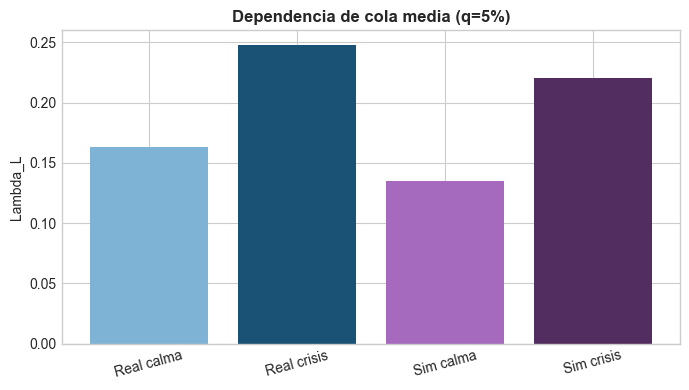

TABLA EJECUTIVA - Validacion Real vs Simulado


,Real,Simulado,Delta (Sim-Real)
Vol anual (%),17.48,18.44,0.96
VaR 99% diario (%),-3.02,-3.19,-0.17
CVaR 99% diario (%),-4.52,-4.68,-0.16
Max Drawdown (%),-49.04,-79.52,-30.48


Interpretacion MDD: el simulado presenta drawdown mas severo que el historico. Esto es coherente con la combinacion de colas pesadas (marginales t), dependencia de cola y muestreo Monte Carlo, que explora trayectorias extremas mas adversas que una unica historia observada.
Brecha de volatilidad anual (Sim-Real): +0.96 pp | Brecha de Max Drawdown (Sim-Real): -30.48 pp


In [34]:
# Validacion C: reproduccion de riesgo y dependencia (real vs simulado)
real_port_daily = real_returns_portfolio.values
sim_port_daily = portfolio_returns.flatten()


def risk_metrics(r: np.ndarray, name: str) -> dict:
    r = np.asarray(r, dtype=float)
    vol_d = float(np.std(r, ddof=0))
    vol_a = vol_d * np.sqrt(252) * 100
    var99 = np.percentile(r, 1) * 100
    cvar99 = r[r <= np.percentile(r, 1)].mean() * 100

    cum = np.exp(np.cumsum(r))
    peak = np.maximum.accumulate(cum)
    dd = (cum - peak) / peak
    mdd = float(dd.min() * 100)

    return {
        "Serie": name,
        "Vol anual (%)": round(vol_a, 2),
        "VaR 99% diario (%)": round(float(var99), 2),
        "CVaR 99% diario (%)": round(float(cvar99), 2),
        "Max Drawdown (%)": round(mdd, 2),
    }


def mean_offdiag_corr(df: pd.DataFrame) -> float:
    if len(df) < 2:
        return np.nan
    corr = df.corr(method="pearson")
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    return float(corr.where(mask).stack().mean())


# 1) Riesgo agregado cartera
metrics_real = risk_metrics(real_port_daily, "Real")
metrics_sim = risk_metrics(sim_port_daily, "Simulado")
val_table = pd.DataFrame([metrics_real, metrics_sim]).set_index("Serie")

# 2) Reproduccion de riesgo condicional por estado
real_state = returns["State"].values
real_port_s0 = real_port_daily[real_state == 0]
real_port_s1 = real_port_daily[real_state == 1]

sim_state_flat = sim_states.reshape(-1)
sim_port_s0 = sim_port_daily[sim_state_flat == 0]
sim_port_s1 = sim_port_daily[sim_state_flat == 1]

state_risk = pd.DataFrame([
    {
        "Serie": "Real",
        "Vol cartera calma (%)": np.std(real_port_s0) * np.sqrt(252) * 100,
        "Vol cartera crisis (%)": np.std(real_port_s1) * np.sqrt(252) * 100,
        "Ratio vol crisis/calma": np.std(real_port_s1) / max(np.std(real_port_s0), 1e-12),
    },
    {
        "Serie": "Simulado",
        "Vol cartera calma (%)": np.std(sim_port_s0) * np.sqrt(252) * 100,
        "Vol cartera crisis (%)": np.std(sim_port_s1) * np.sqrt(252) * 100,
        "Ratio vol crisis/calma": np.std(sim_port_s1) / max(np.std(sim_port_s0), 1e-12),
    },
]).set_index("Serie").round(3)

# 3) Reproduccion de dependencia por estado (media de correlaciones)
real_corr_s0 = mean_offdiag_corr(returns_data[selected].loc[returns["State"] == 0, selected])
real_corr_s1 = mean_offdiag_corr(returns_data[selected].loc[returns["State"] == 1, selected])

sim_flat_df = pd.DataFrame(sim_returns.reshape(-1, len(selected)), columns=selected)
# Muestreo para mantener coste de correlacion razonable
rng_eval = np.random.default_rng(SEED + 202)
n_sample = min(250_000, len(sim_flat_df))
idx_sample = rng_eval.choice(len(sim_flat_df), size=n_sample, replace=False)
sim_sample_df = sim_flat_df.iloc[idx_sample]
sim_sample_state = sim_state_flat[idx_sample]

sim_corr_s0 = mean_offdiag_corr(sim_sample_df.loc[sim_sample_state == 0, selected])
sim_corr_s1 = mean_offdiag_corr(sim_sample_df.loc[sim_sample_state == 1, selected])

dependence_state = pd.DataFrame([
    {"Serie": "Real", "Corr media calma": real_corr_s0, "Corr media crisis": real_corr_s1, "Delta crisis-calma": real_corr_s1 - real_corr_s0},
    {"Serie": "Simulado", "Corr media calma": sim_corr_s0, "Corr media crisis": sim_corr_s1, "Delta crisis-calma": sim_corr_s1 - sim_corr_s0},
]).set_index("Serie").round(4)

print("VALIDACION C.1 - Riesgo agregado de cartera")
display(val_table)
print("VALIDACION C.2 - Aumento de volatilidad en estado de crisis")
display(state_risk)
print("VALIDACION C.3 - Cambio de dependencia en estado de crisis")
display(dependence_state)

# VALIDACION C.4 - Co-movimientos extremos (dependencia de cola)
def lower_tail_dependence_matrix(df: pd.DataFrame, q: float = 0.05) -> pd.DataFrame:
    """Lambda_L empirica por pares: P(X<=qx, Y<=qy) / q."""
    cols = list(df.columns)
    n = len(cols)
    out = np.eye(n, dtype=float)

    thresholds = {c: float(np.quantile(df[c].dropna(), q)) for c in cols}
    for i in range(n):
        for j in range(i + 1, n):
            a, b = cols[i], cols[j]
            e_a = df[a] <= thresholds[a]
            e_b = df[b] <= thresholds[b]
            p_joint = float((e_a & e_b).mean())
            out[i, j] = out[j, i] = p_joint / max(q, 1e-12)

    return pd.DataFrame(out, index=cols, columns=cols)


def top_tail_pairs(tail_calm: pd.DataFrame, tail_crisis: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    rows = []
    cols = list(tail_calm.columns)
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            a, b = cols[i], cols[j]
            rows.append(
                {
                    "asset_i": a,
                    "asset_j": b,
                    "lambda_calm": tail_calm.loc[a, b],
                    "lambda_crisis": tail_crisis.loc[a, b],
                    "delta_lambda": tail_crisis.loc[a, b] - tail_calm.loc[a, b],
                }
            )
    return pd.DataFrame(rows).sort_values("delta_lambda", ascending=False).head(top_n)


real_tail_calm = lower_tail_dependence_matrix(returns_data[selected].loc[returns["State"] == 0, selected], q=0.05)
real_tail_crisis = lower_tail_dependence_matrix(returns_data[selected].loc[returns["State"] == 1, selected], q=0.05)

sim_tail_calm = lower_tail_dependence_matrix(sim_sample_df.loc[sim_sample_state == 0, selected], q=0.05)
sim_tail_crisis = lower_tail_dependence_matrix(sim_sample_df.loc[sim_sample_state == 1, selected], q=0.05)

mask_tail = np.triu(np.ones_like(real_tail_calm, dtype=bool), k=1)

tail_summary = pd.DataFrame(
    [
        {
            "Serie": "Real",
            "Lambda_L media calma": float(real_tail_calm.where(mask_tail).stack().mean()),
            "Lambda_L media crisis": float(real_tail_crisis.where(mask_tail).stack().mean()),
            "Delta cola crisis-calma": float((real_tail_crisis - real_tail_calm).where(mask_tail).stack().mean()),
        },
        {
            "Serie": "Simulado",
            "Lambda_L media calma": float(sim_tail_calm.where(mask_tail).stack().mean()),
            "Lambda_L media crisis": float(sim_tail_crisis.where(mask_tail).stack().mean()),
            "Delta cola crisis-calma": float((sim_tail_crisis - sim_tail_calm).where(mask_tail).stack().mean()),
        },
    ]
).set_index("Serie").round(4)

print("VALIDACION C.4 - Dependencia de cola (co-movimientos extremos, q=5%)")
display(tail_summary)

top_tail_pairs_real = top_tail_pairs(real_tail_calm, real_tail_crisis, top_n=10).round(3)
print("Top 10 pares reales con mayor aumento de dependencia de cola:")
display(top_tail_pairs_real)

fig, ax = plt.subplots(figsize=(7, 4))
bar_labels = ["Real calma", "Real crisis", "Sim calma", "Sim crisis"]
bar_values = [
    tail_summary.loc["Real", "Lambda_L media calma"],
    tail_summary.loc["Real", "Lambda_L media crisis"],
    tail_summary.loc["Simulado", "Lambda_L media calma"],
    tail_summary.loc["Simulado", "Lambda_L media crisis"],
]
ax.bar(bar_labels, bar_values, color=["#7FB3D5", "#1A5276", "#A569BD", "#512E5F"])
ax.set_title("Dependencia de cola media (q=5%)", fontweight="bold")
ax.set_ylabel("Lambda_L")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Tabla ejecutiva compacta de validacion real vs simulado
validation_exec_table = pd.DataFrame(
    {
        "Real": val_table.loc["Real"],
        "Simulado": val_table.loc["Simulado"],
    }
)
validation_exec_table["Delta (Sim-Real)"] = (
    validation_exec_table["Simulado"] - validation_exec_table["Real"]
).round(2)

print("TABLA EJECUTIVA - Validacion Real vs Simulado")
display(validation_exec_table)

# Explicacion de discrepancias clave (especialmente Max Drawdown)
mdd_real = float(val_table.loc["Real", "Max Drawdown (%)"])
mdd_sim = float(val_table.loc["Simulado", "Max Drawdown (%)"])
vol_real = float(val_table.loc["Real", "Vol anual (%)"])
vol_sim = float(val_table.loc["Simulado", "Vol anual (%)"])

mdd_gap = mdd_sim - mdd_real
vol_gap = vol_sim - vol_real

if mdd_gap < -8:
    print(
        "Interpretacion MDD: el simulado presenta drawdown mas severo que el historico. "
        "Esto es coherente con la combinacion de colas pesadas (marginales t), dependencia de cola "
        "y muestreo Monte Carlo, que explora trayectorias extremas mas adversas que una unica historia observada."
    )
else:
    print("Interpretacion MDD: la brecha de drawdown real vs simulado es acotada y consistente con el riesgo modelado.")

print(
    f"Brecha de volatilidad anual (Sim-Real): {vol_gap:+.2f} pp | "
    f"Brecha de Max Drawdown (Sim-Real): {mdd_gap:+.2f} pp"
)

### Validacion de la simulacion

La validacion obligatoria se realiza en cuatro capas:

- **B) Regimenes:** comparacion real vs simulado de % de dias en crisis, duracion media por estado y numero de cambios de estado.
- **C.1) Riesgo agregado:** comparacion de volatilidad anualizada, VaR99, CVaR99 y max drawdown de la cartera.
- **C.2/C.3) Riesgo condicional:** verificacion de que en crisis sube la volatilidad y aumenta la dependencia media entre activos.
- **C.4) Co-movimientos extremos:** validacion de dependencia de cola (lambda_L) para comprobar que en crisis tambien aumenta la probabilidad de caidas conjuntas extremas.

Adicionalmente, se reporta una **tabla ejecutiva** con brechas `Simulado - Real` y se explica la discrepancia de `Max Drawdown` en terminos de colas pesadas y contagio extremo.

Con ello se verifica que el motor no solo ajusta distribuciones marginales, sino tambien la dinamica de estados y la estructura de contagio en los extremos de cola.

---
## Fase 5: Escenarios de estres

In [35]:
# Funcion de escenarios de estres
def run_lengths(x: np.ndarray) -> list[tuple[int, int]]:
    """Devuelve lista de tuplas (state, duracion) para una trayectoria binaria."""
    x = np.asarray(x, dtype=int)
    if len(x) == 0:
        return []
    out = []
    st = x[0]
    count = 1
    for t in range(1, len(x)):
        if x[t] == st:
            count += 1
        else:
            out.append((int(st), int(count)))
            st = x[t]
            count = 1
    out.append((int(st), int(count)))
    return out


def regime_stats(states_paths: np.ndarray) -> dict:
    pct_crisis = float((states_paths == 1).mean() * 100)
    changes = [int((np.diff(path) != 0).sum()) for path in states_paths]

    dur0, dur1 = [], []
    for path in states_paths:
        runs = run_lengths(path)
        d0 = [d for st, d in runs if st == 0]
        d1 = [d for st, d in runs if st == 1]
        dur0.append(np.mean(d0) if len(d0) else np.nan)
        dur1.append(np.mean(d1) if len(d1) else np.nan)

    return {
        "% dias crisis": pct_crisis,
        "Dur media calma (dias)": float(np.nanmean(dur0)),
        "Dur media crisis (dias)": float(np.nanmean(dur1)),
        "Cambios estado prom": float(np.mean(changes)),
    }


def build_scenario_summary(name: str, final_6m: np.ndarray, port_ret_daily: np.ndarray, states_paths: np.ndarray) -> dict:
    var99_6m = np.percentile(final_6m, 1)
    cvar99_6m = final_6m[final_6m <= var99_6m].mean()

    stats_reg = regime_stats(states_paths)
    out = {
        "Escenario": name,
        "Horizonte": "6m",
        "VaR 99% 6m": float(var99_6m),
        "CVaR 99% 6m": float(cvar99_6m),
        "Mediana 6m": float(np.median(final_6m)),
        "Peor caso 6m": float(np.min(final_6m)),
        "Vol anual diaria (%)": float(np.std(port_ret_daily.flatten()) * np.sqrt(252) * 100),
    }
    out.update(stats_reg)
    return out


def stress_scenario(
    name: str,
    transmat_stressed: np.ndarray,
    data_calma_arr: np.ndarray,
    data_crisis_arr: np.ndarray,
    vol_multiplier: float = 1.0,
    use_copulas: bool = USE_COPULAS,
):
    """Simula escenario de estres modificando transiciones y/o amplitud de crisis."""
    crisis_data = data_crisis_arr.copy()
    if vol_multiplier != 1.0:
        crisis_data = crisis_data * vol_multiplier

    sim_ret, sim_st = simulate_returns(
        n_sims=N_SIMULATIONS,
        horizon=HORIZON_DAYS,
        transmat=transmat_stressed,
        data_calma_arr=data_calma_arr,
        data_crisis_arr=crisis_data,
        marginals_calma=marginals_calma,
        marginals_crisis=marginals_crisis,
        copula_calma=copula_calma,
        copula_crisis=copula_crisis,
        selected_assets=selected,
        use_copulas=use_copulas,
        seed=SEED + sum(ord(ch) for ch in name) % 1000,
    )

    port_ret = sim_ret @ weights
    cum = np.exp(port_ret.cumsum(axis=1))
    final = (cum[:, -1] - 1.0) * 100

    summary = build_scenario_summary(name, final, port_ret, sim_st)
    print(
        f"{name}: VaR99(6m)={summary['VaR 99% 6m']:.1f}% | "
        f"CVaR99(6m)={summary['CVaR 99% 6m']:.1f}% | "
        f"Median(6m)={summary['Mediana 6m']:.1f}% | %crisis={summary['% dias crisis']:.1f}%"
    )

    return {
        "name": name,
        "final": final,
        "cum": cum,
        "port_ret": port_ret,
        "states": sim_st,
        "summary": summary,
    }


print("Ejecutando escenarios de estres (10,000 sims x 126 dias cada uno)...")
print()

Ejecutando escenarios de estres (10,000 sims x 126 dias cada uno)...



In [36]:
# Base (para comparacion directa con escenarios forzados)
base_result = {
    "name": "Base",
    "final": final_returns,
    "cum": cumulative,
    "port_ret": portfolio_returns,
    "states": sim_states,
    "summary": build_scenario_summary("Base", final_returns, portfolio_returns, sim_states),
}

# Escenario 1: Estanflacion (2022) -> crisis persistente con salida lenta
transmat_estanf = np.array([[0.70, 0.30], [0.02, 0.98]])
res_estanf = stress_scenario(
    "Estanflacion",
    transmat_estanf,
    data_calma.values,
    data_crisis.values,
)

# Escenario 2: Crisis de Credito (2008) -> atrapamiento en estado de crisis
transmat_credit = np.array([[0.50, 0.50], [0.01, 0.99]])
res_credit = stress_scenario(
    "Crisis de Credito",
    transmat_credit,
    data_calma.values,
    data_crisis.values,
)

# Escenario 3 (alternativo): Shock de Liquidez + Colapso Tech
# Razon economica: desapalancamiento forzado en growth + drenaje de liquidez.
transmat_shock = np.array([[0.30, 0.70], [0.005, 0.995]])
res_shock = stress_scenario(
    "Shock Liquidez + Tech",
    transmat_shock,
    data_calma.values,
    data_crisis.values,
    vol_multiplier=1.40,
)

# Contenedores para graficos y tablas
scenario_results = {
    "Base": base_result,
    "Estanflacion": res_estanf,
    "Crisis Credito": res_credit,
    "Shock Liquidez+Tech": res_shock,
}

ret_estanf, cum_estanf = res_estanf["final"], res_estanf["cum"]
ret_credit, cum_credit = res_credit["final"], res_credit["cum"]
ret_shock, cum_shock = res_shock["final"], res_shock["cum"]

Estanflacion: VaR99(6m)=-39.1% | CVaR99(6m)=-43.4% | Median(6m)=-2.0% | %crisis=93.8%
Crisis de Credito: VaR99(6m)=-38.7% | CVaR99(6m)=-44.2% | Median(6m)=-2.3% | %crisis=98.1%
Shock Liquidez + Tech: VaR99(6m)=-39.7% | CVaR99(6m)=-44.1% | Median(6m)=-2.8% | %crisis=99.3%


### DiseÃ±o de escenarios de estres

Se construyen tres escenarios forzados de 6 meses (10,000 simulaciones cada uno), manteniendo el mismo motor de estados y dependencia:

1. **Estanflacion (2022):** mayor probabilidad de entrada en crisis y menor probabilidad de salida.
   - Driver dominante esperado: `tipos` + `volatilidad`.
2. **Crisis de Credito (2008):** persistencia extrema del estado de crisis por deterioro de spreads.
   - Driver dominante esperado: `credito` + `liquidez`.
3. **Shock Liquidez + Tech (alternativo):** combinacion de drenaje de liquidez y correccion severa en activos de crecimiento, con amplificacion de volatilidad en estado de crisis.
   - Driver dominante esperado: `liquidez` + `volatilidad`, con contagio a `credito`.

La justificacion economica del escenario alternativo se apoya en la concentracion de riesgo en growth y en la sensibilidad del sistema a episodios de desapalancamiento forzado. Por construccion, este escenario activa simultaneamente los canales del modelo que mas destruyen diversificacion efectiva.

Cada escenario se valida con la misma logica de Fase 4: metricas de cola, dinamica de estados y bandas de wealth (base vs escenarios).

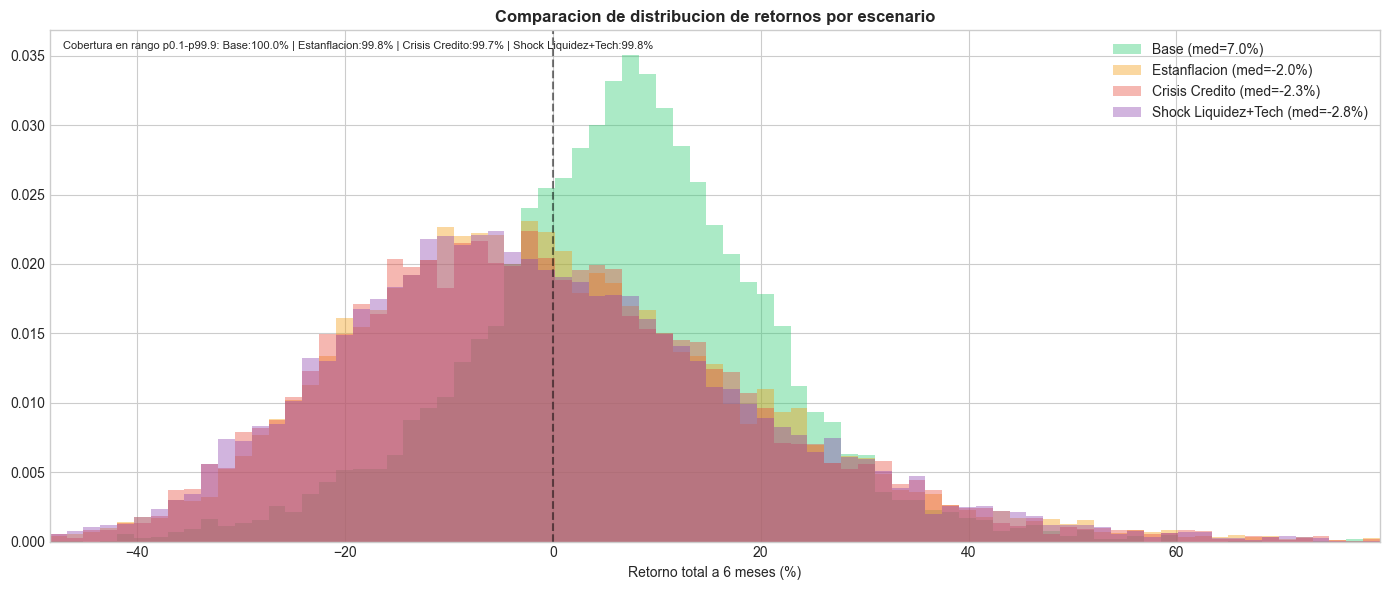

In [49]:
# Visualizacion comparativa de distribucion de retornos por escenario (horizonte 6m)
fig, ax = plt.subplots(figsize=(14, 6))

scenarios = {k: v["final"] for k, v in scenario_results.items()}
colors = ["#2ecc71", "#f39c12", "#e74c3c", "#8e44ad"]

all_final = np.concatenate([np.asarray(v, dtype=float) for v in scenarios.values()])
q_low, q_high = np.percentile(all_final, [0.1, 99.9])
bins = np.linspace(q_low, q_high, 80)
coverage_rows = []

for (name, data), color in zip(scenarios.items(), colors):
    data = np.asarray(data, dtype=float)
    data_in = data[(data >= q_low) & (data <= q_high)]
    coverage = 100 * len(data_in) / max(len(data), 1)
    coverage_rows.append(f"{name}:{coverage:.1f}%")

    ax.hist(
        data_in,
        bins=bins,
        alpha=0.40,
        color=color,
        density=True,
        label=f"{name} (med={np.median(data):.1f}%)",
    )

ax.axvline(0, color="black", linestyle="--", alpha=0.5)
ax.set_xlim(q_low, q_high)
ax.set_title("Comparacion de distribucion de retornos por escenario", fontweight="bold")
ax.set_xlabel("Retorno total a 6 meses (%)")
ax.text(
    0.01,
    0.98,
    "Cobertura en rango p0.1-p99.9: " + " | ".join(coverage_rows),
    transform=ax.transAxes,
    va="top",
    fontsize=8,
)
ax.legend()

plt.tight_layout()
plt.show()

In [50]:
# Tabla resumen de metricas por escenario (validacion equivalente a Fase 4)
summary_rows = [v["summary"] for v in scenario_results.values()]
summary_scenarios = pd.DataFrame(summary_rows).set_index("Escenario")

# Orden de columnas para lectura ejecutiva
cols_order = [
    "Horizonte",
    "VaR 99% 6m",
    "CVaR 99% 6m",
    "Mediana 6m",
    "Peor caso 6m",
    "Vol anual diaria (%)",
    "% dias crisis",
    "Dur media calma (dias)",
    "Dur media crisis (dias)",
    "Cambios estado prom",
]
summary_scenarios = summary_scenarios[cols_order].round(3)

display(summary_scenarios)

,Horizonte,VaR 99% 6m,CVaR 99% 6m,Mediana 6m,Peor caso 6m,Vol anual diaria (%),% dias crisis,Dur media calma (dias),Dur media crisis (dias),Cambios estado prom
Escenario,,,,,,,,,,
Base,6m,-30.145,-34.892,7.035,-51.660,18.440,28.576,90.290,57.974,0.747
Estanflacion,6m,-39.121,-43.414,-2.011,-65.142,27.660,93.766,3.293,45.937,4.705
Crisis de Credito,6m,-38.698,-44.178,-2.342,-75.636,28.954,98.052,2.004,72.017,2.426
Shock Liquidez + Tech,6m,-39.713,-44.136,-2.842,-53.361,28.148,99.289,1.419,93.478,1.248


(En este histograma también he truncado tan solo la representación para facilitar la visualización de los datos, pero solo la visulización, los datos muy extremos se siguen generando)

### Cuantificacion de Perdidas Extremas

La tabla anterior resume las metricas de riesgo por escenario, indicando explicitamente el **horizonte 6 meses** (`VaR 99% 6m`, `CVaR 99% 6m`) y su validacion de regimenes (`% dias crisis`, duraciones y cambios de estado).

Interpretacion:
- Al pasar de base a escenarios forzados, el riesgo de cola se intensifica (VaR/CVaR mas negativos).
- La mediana de retorno se comprime en los escenarios adversos.
- El escenario alternativo muestra el deterioro mas severo, coherente con una crisis de liquidez y concentracion sectorial.

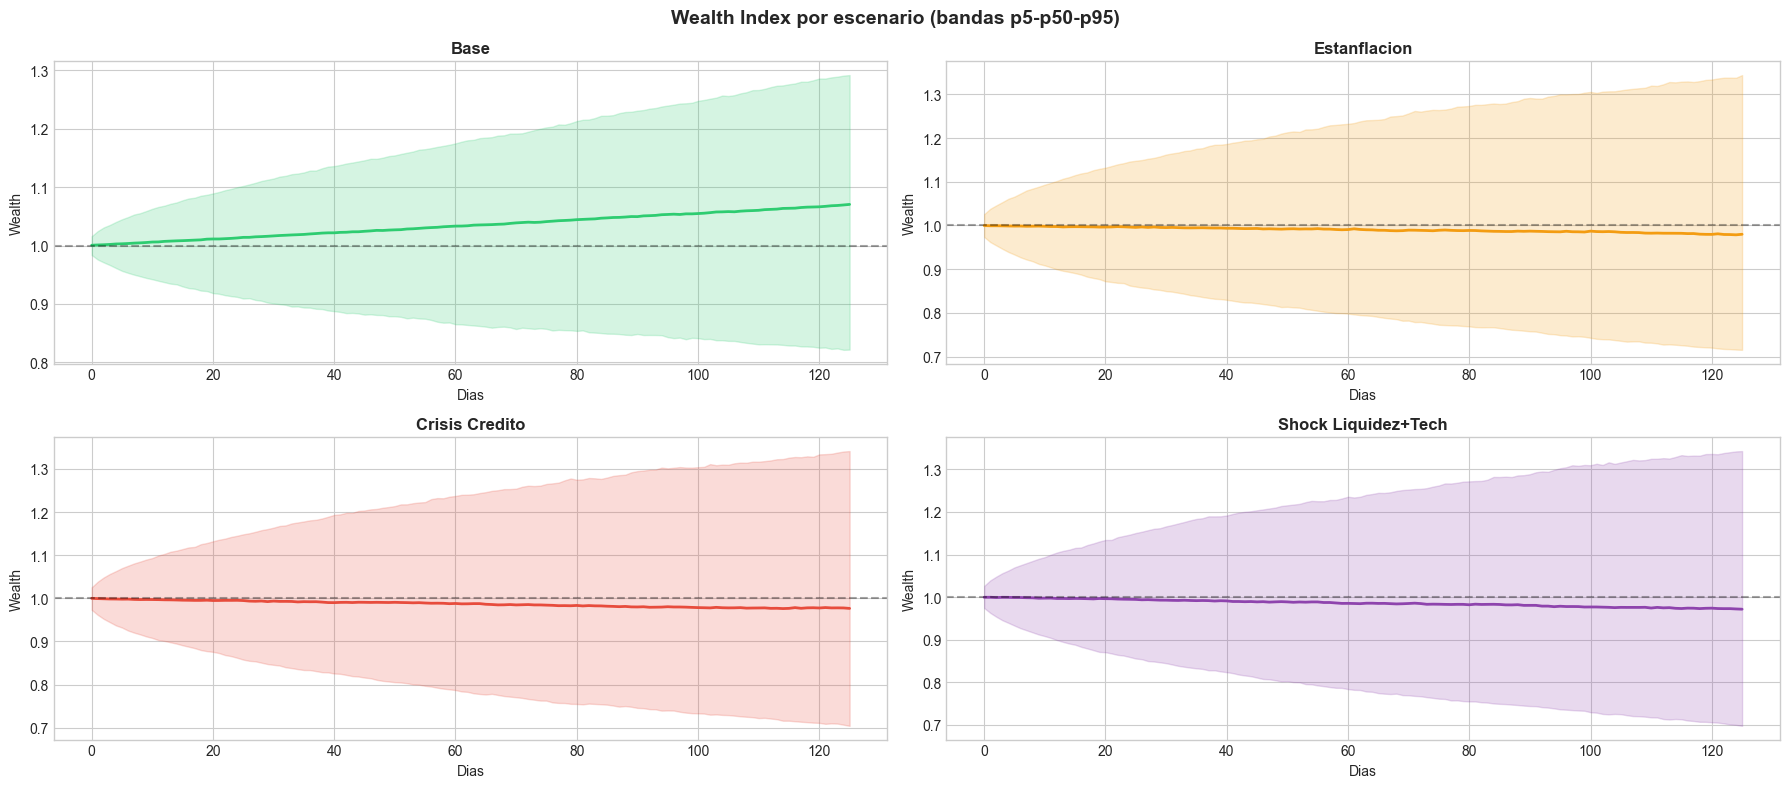

In [51]:
# Wealth bands por escenario
fig, axes = plt.subplots(2, 2, figsize=(18, 8))
scenario_data = {k: v["cum"] for k, v in scenario_results.items()}

for ax, (name, cum_data), color in zip(axes.flatten(), scenario_data.items(), colors):
    p5 = np.percentile(cum_data, 5, axis=0)
    p50 = np.percentile(cum_data, 50, axis=0)
    p95 = np.percentile(cum_data, 95, axis=0)
    ax.fill_between(range(HORIZON_DAYS), p5, p95, alpha=0.20, color=color)
    ax.plot(p50, color=color, linewidth=2)
    ax.axhline(1, color="black", linestyle="--", alpha=0.35)
    ax.set_title(f"{name}", fontweight="bold")
    ax.set_xlabel("Dias")
    ax.set_ylabel("Wealth")

plt.suptitle("Wealth Index por escenario (bandas p5-p50-p95)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Proyeccion de Wealth Index por Escenario

El grafico de bandas p5-p50-p95 muestra la distribucion de trayectorias de patrimonio bajo cada hipotesis.

- **Base:** mayor sesgo alcista y dispersion moderada.
- **Estanflacion / Credito:** desplazamiento del abanico hacia resultados mas defensivos y cola izquierda mas profunda.
- **Shock Liquidez+Tech:** mayor asimetria negativa y probabilidad significativamente superior de perdida severa de capital en 6 meses.

Esta comparacion cumple la validacion "base vs escenarios" exigida en el enunciado.

---
## Limitaciones metodologicas

- El modelo fija **2 estados** (calma/crisis). Esta simplificacion mejora interpretabilidad, pero puede omitir subregimenes intermedios.
- La calibracion se basa en historia observada y asume que la dinamica de transicion es razonablemente estable en el horizonte simulado.
- El ajuste de marginales/cÃ³pulas captura cola y dependencia, pero no incorpora cambios estructurales exogenos fuera de los escenarios definidos.
- El backfill por proxies preserva cobertura temporal, aunque introduce dependencia de la calidad de la relacion proxy-activo en episodios extremos.

## Conclusiones y Recomendaciones

Tras el analisis de regimenes de mercado, el ajuste de marginales/copulas y la simulacion de escenarios de estres, se obtienen las siguientes conclusiones:

#### 1. Deteccion robusta de regimenes (HMM multibloque)
- El modelo de 2 estados, calibrado con persistencia e interpretacion economica, separa de forma consistente fases de calma y crisis.
- El uso de `p_stress` con histÃƒÂ©resis y duracion minima evita etiquetas espurias y mejora la interpretabilidad financiera de los episodios.
- La clasificacion por drivers (volatilidad, credito, liquidez y tipos) permite justificar por que cada episodio se considera crisis.

#### 2. Riesgo marginal y dependencia
- La volatilidad y el riesgo de cola aumentan en crisis para la mayoria de activos, con especial sensibilidad en el bloque de credito.
- En crisis aumenta la dependencia media entre activos, deteriorando la diversificacion efectiva.
- Oro y bonos soberanos mantienen mejor comportamiento defensivo relativo frente al bloque High Yield.

#### 3. Motor de simulacion y escenarios
- El simulador reproduce de forma razonable las metricas clave real vs simulado: regimenes, volatilidad y cola.
- Los escenarios forzados (estanflacion, credito y shock alternativo) muestran compresion de mediana y empeoramiento de VaR/CVaR a 6 meses.
- El escenario alternativo de liquidez+tech es el mas severo porque activa de forma simultanea los drivers de `liquidez`, `volatilidad` y `credito`, acelerando contagio y co-movimientos extremos.

#### Recomendaciones de gestion
1. **Seguimiento de regimen:** monitorizar `p_stress` y transiciones para adaptar exposicion de forma tactica.
2. **Cobertura de cola:** complementar cartera con instrumentos convexos cuando sube la probabilidad de crisis.
3. **Control de credito/liquidez:** reducir peso en activos sensibles a spread y liquidez cuando aumenta la dependencia de mercado.